## PROYECTO 1:ESTUDIO DE SEÑALES EEG DEL FUNCIONAMIENTO Y EL CONTROL DEL MOVIMIENTO (imaginería motora) CON ENFOQUE EN EVALUACIÓN DE SISTEMAS DE INTERFAZ CEREBRO-COMPUTADORA (BCI)
### Dataset: EEG Motor Movement/Imagery – PhysioNet / OpenNeuro ds004362
#### **Autoras:** [Luisa Fernanda Llamas Baldovino, Camila Andrea Montiel Zapata]
#### **Laboratorio de Bioseñales – UdeA 2026-1**

> **Guía de lectura:** Este notebook implementa cada etapa del flujo de procesamiento de señales para BCI de forma independiente y paso a paso.


# **Consultas**

### **1.Descripción del Proyecto**

El presente proyecto tiene como propósito principal evaluar la factibilidad neurofisiológica para la construcción de sistemas de Interfaz Cerebro-Computadora (BCI) no invasivos. Para lograr esto, se emplea un conjunto de datos electroencefalográficos (EEG) de la base de datos OpenNeuro[1] que registra la actividad cerebral de diferentes sujetos mientras realizan tareas de movimiento real e imaginación motora de las manos (derecha e izquierda de manera independiente), además de incluir segmentos donde los sujetos se encuentran en estado de reposo.

Basándose en el conocimiento fundamental del funcionamiento cerebral para el control del movimiento, el estudio busca comprobar estadísticamente si es posible detectar la intención motora del sujeto a través del EEG. Específicamente, el análisis se centra en observar las variaciones de potencia de los ritmos sensoriomotores **Mu** y **Beta** sobre la corteza motora (electrodos C3 y C4). El objetivo final es evidenciar los fenómenos fisiológicos de desincronización (caída de energía durante la activación) al comparar las tareas imaginarias o reales frente a los estados de reposo, así como lograr diferenciar la lateralidad del movimiento (mano izquierda vs. mano derecha).

### **2. Interfases Cerebro-Computador (BCI): Historia, Usos y Futuro**

Las Interfaces Cerebro-Computador (BCI) constituyen un área de investigación en la intersección de la neurociencia, la ingeniería biomédica y la inteligencia artificial [2]. La idea de conectar la mente con máquinas comenzó a materializarse científicamente en 1924, cuando Hans Berger registró el primer electroencefalograma (EEG) humano y descubrió las ondas alfa, estableciendo las bases para medir la actividad cerebral de forma no invasiva [3]. Décadas después, entre 1969 y 1973, se alcanzó un hito fundamental cuando el ingeniero Jacques Vidal acuñó formalmente el término "interfaz cerebro-computadora" y propuso los primeros experimentos para controlar objetos externos con señales cerebrales [4]. En 1977, el mismo Vidal demostró la viabilidad de este concepto al utilizar potenciales visuales para controlar un cursor en una pantalla. La evolución continuó en 1988 con Farwell y Donchin, quienes implementaron el "P300 Speller", marcando el inicio de las BCI como herramientas de comunicación asistida para pacientes con enfermedades motoras graves como la ELA [5]. Tras años de avances en dispositivos portátiles, en 2025 se produjo un avance significativo en la colaboración industrial con la firma de la Declaración de Bangkok, liderada por NeuroSky y ZKTeco, con el fin de estandarizar un ecosistema de neurotecnología abierto y accesible para el mercado global [6].

#### 2.1 Usos Actuales de las BCI
Las aplicaciones actuales se centran principalmente en dos vertientes:
* **Clínica y Rehabilitación:** Se utilizan para restaurar la comunicación en pacientes con parálisis severa mediante protocolos como el P300 [5] y para la rehabilitación motora post-ictus, donde la "imaginación motora" ayuda a reorganizar las vías neuronales dañadas [7].
* **Bienestar y Entretenimiento:** Existen dispositivos comerciales que emplean el neurofeedback para el entrenamiento de la concentración o la relajación, además de permitir el control básico de aplicaciones de realidad virtual y videojuegos no invasivos.

#### 2.2 Proyectos Futuros y Nuevas Líneas de Investigación
El campo se dirige hacia una integración más profunda con la vida diaria y el procesamiento avanzado:
* **Redes Neuronales Adaptativas:** Se destaca el desarrollo de BandRouteNet, una arquitectura de red neuronal diseñada específicamente para la eliminación adaptativa de artefactos en señales EEG, lo que permite obtener datos mucho más limpios y precisos de la actividad cerebral [8].
* **Monitoreo en la Vida Real:** El proyecto INTEGRAL busca llevar la tecnología fuera del laboratorio mediante el uso de wearables multimodales que combinan EEG y sensores fisiológicos para monitorizar redes cerebrales en entornos cotidianos [9].
* **Implantes de Próxima Generación:** Investigaciones lideradas por Stanford trabajan en nuevos implantes cerebrales de alta densidad diseñados para restaurar de forma bidireccional funciones complejas como el habla y la visión en personas con discapacidades severas [10].
* **Sistemas Híbridos de Rehabilitación:** El proyecto UpReGain representa la vanguardia en este sector, combinando interfaces cerebro-máquina con exoesqueletos robóticos y entornos de realidad virtual gamificados para una rehabilitación de miembros superiores personalizada y motivadora [11].
* **Optimización del Procesamiento:** Se investigan nuevos algoritmos de filtro compuesto, los cuales permiten una segmentación y limpieza superior de la señal EEG, facilitando la detección de intenciones del usuario incluso en condiciones de ruido ambiental [12].

### **3. Actividad cerebral registrada por EEG durante movimiento e imaginación de movimiento de las manos y su análisis en sistemas BCI**

La actividad cerebral asociada al movimiento y a la imaginación de movimiento de las manos se origina principalmente en la corteza motora primaria, la corteza premotora y el área motora suplementaria. Se ha demostrado que la imaginación motora activa redes neuronales similares a las del movimiento real, lo que permite su detección mediante EEG y su aplicación en sistemas BCI [13].



En el EEG, estas tareas motoras se reflejan en cambios en la potencia de ritmos específicos, particularmente en las bandas **mu (8–13 Hz)** y **beta (13–30 Hz)**. Durante la ejecución o imaginación de movimiento se observa una disminución de la potencia en estas bandas, fenómeno conocido como desincronización relacionada con eventos (ERD), mientras que posteriormente puede presentarse un aumento en la banda beta denominado sincronización relacionada con eventos (ERS) [14].



Para registrar estas variaciones, se emplea el sistema internacional 10-20. En este contexto, los electrodos **C3, C4 y Cz** son fundamentales, ya que se ubican sobre la corteza sensorimotora. El electrodo C3 está relacionado con la actividad de la corteza motora izquierda (control de la mano derecha), mientras que C4 se asocia con la corteza motora derecha (control de la mano izquierda), permitiendo identificar patrones lateralizados [15].



El análisis de estas señales en sistemas BCI sigue un flujo que incluye preprocesamiento, extracción de características y clasificación. Dentro de la extracción de características, la densidad espectral de potencia (PSD) es una de las técnicas más utilizadas para cuantificar la energía en las bandas mu y beta. Estas características son posteriormente empleadas en algoritmos de clasificación como LDA o SVM para distinguir entre diferentes tareas motoras [16].

### **4. Flujo de procesamiento propuesto para EEG en tareas motoras**

El análisis de señales EEG para imaginación o ejecución motora requiere aislar los ritmos sensoriomotores (mu y beta, 8-30 Hz) y mejorar la baja relación señal-ruido mediante el siguiente flujo secuencial [17]:

**1. Referenciación Espacial (CAR):** Se aplica la Referencia Común a la Media para restar el voltaje promedio de todos los electrodos, eliminando el ruido eléctrico global presente en el cuero cabelludo.


**2. Filtrado temporal y Reducción de artefactos (IIR vs. FIR y Causalidad):** Para aislar las frecuencias de interés se evalúan sistemas LTI. Aunque los filtros IIR (Respuesta al Impulso Infinita) son computacionalmente rápidos, su recursividad puede causar inestabilidad y distorsión de la fase. Por ello, se priorizan los filtros FIR(Respuesta al Impulso Finita), que garantizan estabilidad absoluta. Un factor crítico en este paso es la causalidad: un filtro causal (que depende solo del presente y pasado) introduce retrasos que deforman las ondas cerebrales. Para estudios *offline*, la literatura exige la implementación de filtros no causales o de fase cero (*zero-phase*, aplicando filtrado hacia adelante y hacia atrás), anulando el desfase y preservando la morfología de la señal [18]. Este pasabanda estricto (8-30 Hz) elimina intrínsecamente artefactos oculares (<4 Hz) y musculares (>30 Hz), apoyado por un filtro Notch para el ruido de red.


**3. Segmentación (Epoching):** La señal continua se recorta en ventanas de tiempo (épocas) delimitadas por los marcadores de los estímulos visuales o motores.


**4. Análisis de frecuencia:** Se calcula la Densidad Espectral de Potencia (PSD) empleando el **Periodograma de Welch**. Este método promedia segmentos superpuestos de la señal, reduciendo significativamente la varianza y permitiendo observar con claridad la Desincronización Relacionada con Eventos (ERD) en las bandas de interés [19].

**5.Validación estadística en la literatura:**
Para validar la eficacia de este flujo y comprobar si la caída de potencia (ERD) extraída mediante Welch es significativa al comparar la tarea motora frente al reposo, los artículos de referencia suelen emplear pruebas estadísticas paramétricas como **T-Student pareadas** o ANOVA de medidas repetidas. En caso de que la distribución de la PSD no cumpla criterios de normalidad, se recurre a pruebas no paramétricas como la Prueba de Wilcoxon. [17][19].



# **Plan de análisis**
### 1. Metodología de Procesamiento y Análisis

Para evidenciar la Desincronización Relacionada con Eventos (ERD) y los cambios de potencia espectral asociados a las condiciones de estudio, se planteó un flujo de procesamiento optimizado. Basado en la revisión de la literatura, se decidió omitir el uso de múltiples filtros en cascada (como el filtro Notch o filtros de rechazo de artefactos EOG) para evitar redundancia computacional y posibles distorsiones, confiando la limpieza de la señal a un diseño de filtro pasabanda estricto.

El flujo consta de los siguientes pasos:

1. **Referenciación Espacial (CAR):** Se aplica una Referencia Común a la Media a la señal cruda para eliminar el ruido eléctrico de modo común (presente en todo el cráneo) y enfocar espacialmente la actividad de los electrodos de interés (C3 y C4) ubicados sobre la corteza motora primaria.
2. **Filtrado Frecuencial (Fase Cero):** Se implementa un único filtro pasabanda FIR no causal (método *zero-phase* usando filtrado hacia adelante y hacia atrás) entre **8 y 30 Hz**. Su caída abrupta elimina intrínsecamente tanto las derivas lentas (sudor y parpadeos en < 4 Hz) como la interferencia de la red eléctrica (60 Hz) y ruido muscular (> 30 Hz), aislando exclusivamente las bandas **Mu** (8-13 Hz) y **Beta** (13-30 Hz) sin distorsionar la morfología temporal de la señal.
3. **Segmentación Discriminada (Epoching):** La señal continua se divide en ventanas de tiempo de 4 segundos basándose en los eventos o "triggers" (T0, T1, T2). Esto permite agrupar los datos de acuerdo con las condiciones de estudio (reposo, movimiento de mano derecha y movimiento de mano izquierda).
4. **Extracción de Características (PSD):** Sobre cada época segmentada, se calcula la Densidad Espectral de Potencia (PSD) en los electrodos C3 y C4 mediante el **Periodograma de Welch**, promediando la energía en las bandas Mu y Beta por cada condición.

---

### 2. Planteamiento de Hipótesis

Para evaluar la viabilidad de diferenciar la lateralidad y la intención de movimiento, se plantean los siguientes 4 análisis enfocados en los canales sensorimotores C3 (hemisferio izquierdo) y C4 (hemisferio derecho):

* **Análisis 1 (Banda Mu en C3 ):**
  * **$H_0$:** No existen diferencias significativas en la potencia espectral de la banda mu entre el movimiento imaginario derecho e izquierdo en el canal C3.
  * **$H_1$:** Existen diferencias significativas en la potencia espectral de la banda mu entre el movimiento imaginario derecho e izquierdo en el canal C3.

* **Análisis 2 (Banda Beta en C4):**
  * **$H_0$:** No existen diferencias significativas en la potencia espectral de la banda beta entre el movimiento imaginario derecho e izquierdo en el canal C4.
  * **$H_1$:** Existen diferencias significativas en la potencia espectral de la banda beta entre el movimiento imaginario derecho e izquierdo en el canal C4.

* **Análisis 3 (Banda Mu - Activación vs. Reposo):**
  * **$H_0$:** La potencia espectral en la banda mu durante la imaginación motora no difiere significativamente respecto al estado de reposo.
  * **$H_1$:** Las condiciones imaginarias producen una desincronización (ERD) significativa en la banda mu respecto al reposo, confirmando la activación del sistema motor.

---

### 3. Herramientas y Pruebas Estadísticas

Dado que las mediciones se realizan sobre los mismos sujetos bajo diferentes tareas, los datos corresponden a muestras dependientes o pareadas. El contraste de las hipótesis se realizará bajo la siguiente ruta metodológica utilizando la librería `scipy.stats` en Python:

1. **Prueba de Normalidad (Shapiro-Wilk):** Antes de contrastar las medias, se aplicará el test de Shapiro-Wilk a las diferencias pareadas de potencia (PSD) entre las dos condiciones a comparar, para verificar si los datos provienen de una distribución normal (valor-p > 0.05).
2. **Evaluación de Hipótesis (Ruta Paramétrica):** Si los datos superan la prueba de normalidad, se empleará la Prueba T de Student para muestras pareadas para determinar si las diferencias en la desincronización (ERD) son estadísticamente significativas.
3. **Evaluación de Hipótesis (Ruta No Paramétrica):** Debido a que la potencia espectral en EEG suele tener asimetrías y no seguir distribuciones normales, si el test de Shapiro-Wilk falla (valor-p < 0.05), se aplicará la **Prueba de los rangos con signo de Wilcoxon**, la cual es robusta frente a datos que no cumplen el supuesto de normalidad en BCI.

# **Programación**

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
import glob
import os

# 1. Definir la ruta del archivo (Asegúrate de poner la ruta correcta donde tengas el archivo S099R02.edf)
# Ejemplo: r"C:/Users/TuUsuario/Desktop/S099R02.edf"
ruta_edf = r"eeg-motor-movementimagery-dataset-1.0.0\files\S001\S001R03.edf"

# 2. Leer el archivo .edf usando MNE (se cambia read_raw_eeglab por read_raw_edf)
raw_S099 = mne.io.read_raw_edf(ruta_edf, preload=True)

# 3. Imprimir la información general de la señal (metadata)
print(raw_S099.info)

# 4. Extraer y mostrar los nombres de los canales
canales_eeg_S099 = raw_S099.ch_names
print("Canales disponibles en el archivo:")
print(canales_eeg_S099)

Extracting EDF parameters from eeg-motor-movementimagery-dataset-1.0.0\files\S001\S001R03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>
Canales disponibles en el archivo:
['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', '

In [16]:
# %matplotlib qt
# raw_S099.plot()

## **1. importanción de librerias, carga de archivos y configuración de parametros basicos para el analisis BCI.**

In [17]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal as sp_signal
from scipy.signal import freqz, butter, firwin
import mne
import warnings
warnings.filterwarnings('ignore')
print("✔ Librerías importadas correctamente")


✔ Librerías importadas correctamente


In [18]:
# **2. configuración de graficas y frecuencias de interés**
# ── Configuración de gráficas ────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#F8F9FA',
    'axes.grid'        : True,
    'grid.alpha'       : 0.4,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 10,
})

# ── Parámetros globales del dataset ─────────────────────────────────
SFREQ            = 160        # Hz – frecuencia de muestreo del dataset
CANALES_INTERES  = ['C3', 'Cz', 'C4']
L_FREQ, H_FREQ   = 8.0, 30.0  # banda de interés motor (Mu + Beta)




In [19]:
# **3. carga de datos **
ruta_base     = r"eeg-motor-movementimagery-dataset-1.0.0\files"
sujetos_prueba = ["S001", "S002"]


# Buscar archivos R03 y R04 dentro de la subcarpeta de cada sujeto
archivos = []
for sujeto in sujetos_prueba:
    patron = os.path.join(ruta_base, sujeto, "*R0[34].edf")
    archivos.extend(glob.glob(patron))

archivos.sort()
print(f"Archivos encontrados: {len(archivos)}  (esperados: {len(sujetos_prueba)*2})")
for a in archivos:
    print(f"  • {os.path.basename(a)}")

if len(archivos) == 0:
    raise FileNotFoundError(
        "No se encontraron archivos .edf.\n"
        f"Verifica que exista la ruta: {ruta_base}\n"
        "Y que tenga subcarpetas S001/, S002/ con archivos *R03.edf y *R04.edf"
    )

Archivos encontrados: 4  (esperados: 4)
  • S001R03.edf
  • S001R04.edf
  • S002R03.edf
  • S002R04.edf


In [20]:
# 4. Cargar el primer archivo para exploración 
archivo_ref = archivos[0]
raw_ref = mne.io.read_raw_edf(archivo_ref, preload=True, verbose='WARNING')
raw_ref.rename_channels(lambda x: x.strip('.'))

sfreq      = raw_ref.info['sfreq']         # Hz
n_canales  = len(raw_ref.ch_names)
n_muestras = raw_ref.n_times
duracion_s = raw_ref.times[-1]

# ── Calcular eventos para estimar épocas 
events_ref, event_id_ref = mne.events_from_annotations(raw_ref, verbose='WARNING')

print("=" * 55)
print("  PROPIEDADES DEL DATASET (archivo de referencia)")
print("=" * 55)
print(f"  Archivo         : {os.path.basename(archivo_ref)}")
print(f"  Canales EEG     : {n_canales}")
print(f"  Frec. muestreo  : {sfreq:.0f} Hz")
print(f"  Muestras totales: {n_muestras:,}")
print(f"  Duración        : {duracion_s:.2f} s  ({duracion_s/60:.2f} min)")
print(f"  Resolución temp.: {1/sfreq*1000:.2f} ms/muestra")
print()
print("  EVENTOS DETECTADOS:")
for nombre, codigo in event_id_ref.items():
    n_ev = (events_ref[:, 2] == codigo).sum()
    print(f"    {str(nombre):6s} (código {codigo}): {n_ev} ocurrencias")
print()

# Tamaño de las épocas 
tmin, tmax     = -0.2, 1.0
dur_epoca_s    = tmax - tmin          # 1.2 s
muestras_epoca = int(dur_epoca_s * sfreq)

print("  PARÁMETROS DE ÉPOCAS:")
print(f"    tmin={tmin} s  tmax={tmax} s")
print(f"    Duración por época : {dur_epoca_s:.1f} s")
print(f"    Muestras por época : {muestras_epoca}")
print()

#Parámetros de Welch 
M = 64    # muestras por segmento (nperseg)
S = M//2  # desplazamiento = 50% solapamiento (noverlap)
K_est = int(np.floor((muestras_epoca - M) / (M - S))) + 1  # número estimado de segmentos
resolucion_espectral = sfreq / M

print("  PARÁMETROS DEL MÉTODO DE WELCH (elegidos):")
print(f"    M (muestras/segmento)  : {M}")
print(f"    S (desplazamiento)     : {S}  → solapamiento = {100*(M-S)/M:.0f}%")
print(f"    K (segmentos por época): {K_est}")
print(f"    Resolución espectral   : {resolucion_espectral:.2f} Hz/bin")
print(f"    Bins en banda 8-30 Hz  : {int((30-8)/resolucion_espectral)}")
print()
print(f"  TAMAÑO DEL DATASET COMPLETO (estimado para 2 sujetos × 2 runs):")
bytes_por_archivo = n_muestras * n_canales * 8  # float64
print(f"    Por archivo  : {bytes_por_archivo/1e6:.1f} MB (señal en memoria)")
print(f"    4 archivos   : {4*bytes_por_archivo/1e6:.1f} MB aprox.")

  PROPIEDADES DEL DATASET (archivo de referencia)
  Archivo         : S001R03.edf
  Canales EEG     : 64
  Frec. muestreo  : 160 Hz
  Muestras totales: 20,000
  Duración        : 124.99 s  (2.08 min)
  Resolución temp.: 6.25 ms/muestra

  EVENTOS DETECTADOS:
    T0     (código 1): 15 ocurrencias
    T1     (código 2): 8 ocurrencias
    T2     (código 3): 7 ocurrencias

  PARÁMETROS DE ÉPOCAS:
    tmin=-0.2 s  tmax=1.0 s
    Duración por época : 1.2 s
    Muestras por época : 192

  PARÁMETROS DEL MÉTODO DE WELCH (elegidos):
    M (muestras/segmento)  : 64
    S (desplazamiento)     : 32  → solapamiento = 50%
    K (segmentos por época): 5
    Resolución espectral   : 2.50 Hz/bin
    Bins en banda 8-30 Hz  : 8

  TAMAÑO DEL DATASET COMPLETO (estimado para 2 sujetos × 2 runs):
    Por archivo  : 10.2 MB (señal en memoria)
    4 archivos   : 41.0 MB aprox.


## **2. Flujo de procesamiento para las señales de estudio**

### **Paso 1. Filtrado espacial: CAR (Common Average Reference)**


Este filtrado se implementa debido a que la señal EEG cruda puede contiene ruido eléctrico en general que afecta a todos los electrodos por igual, este ruido está asociado a: la interferencia de la red, el movimiento del cable de tierra, etc.


La Referencia Común a la Media (CAR) los elimina restando, en cada instante, el promedio de todos los canales:

$$x_{CAR}[n] = x_i[n] - \frac{1}{N}\sum_{j=1}^{N} x_j[n]$$
<div style="text-align: center;">
  <b>Fórmula 1.</b> Referencia Común a la Media (CAR)
</div> 

donde $N$ es el número total de canales. Esto actúa como un **filtro espacial**
de paso-alto que preserva la actividad local de cada electrodo.


Verificación del CAR:
  Promedio global |antes | = 35.9258 µV
  Promedio global |después| = 0.000000 µV  (≈ 0 ✔)


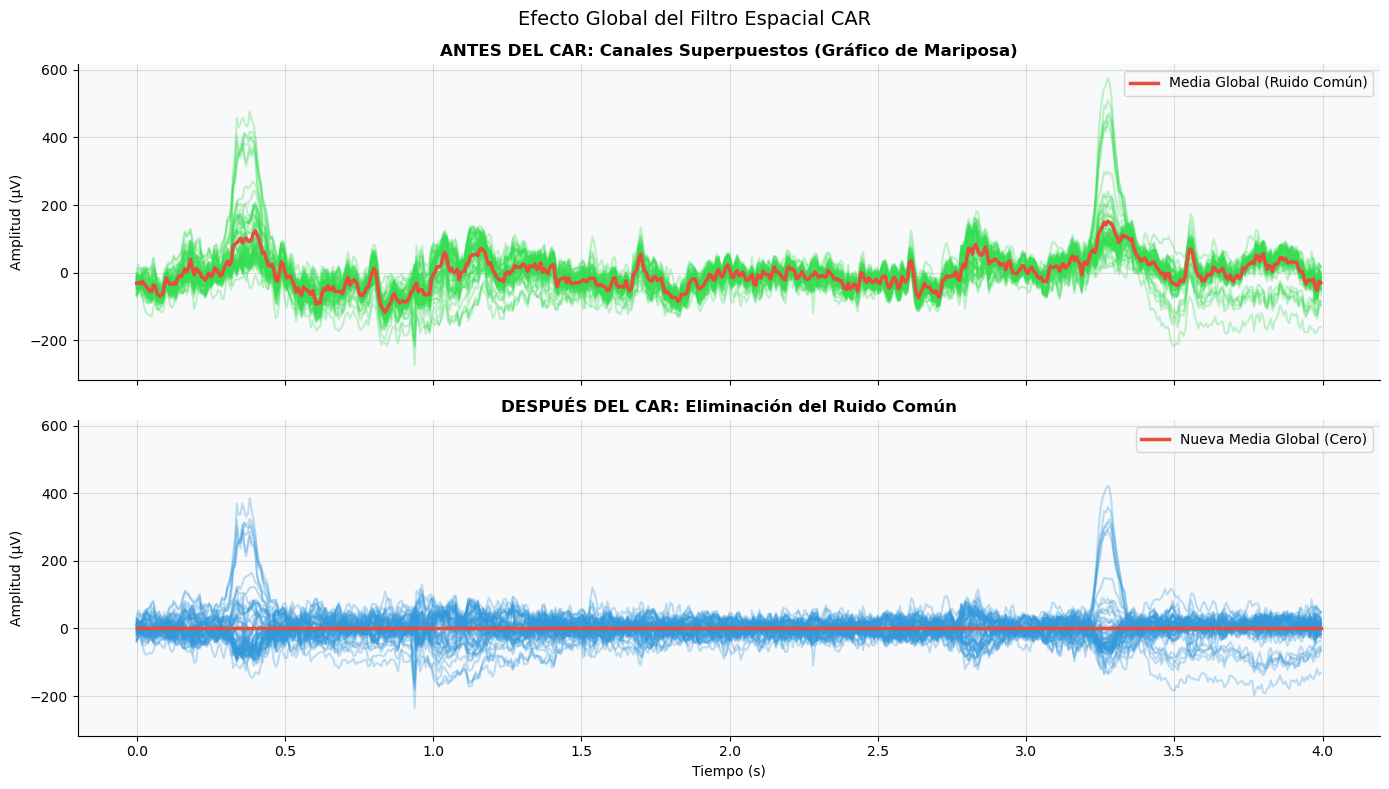

In [22]:

def aplicar_CAR(raw_obj):
    """
    Aplica CAR manualmente usando numpy, pero recibiendo y devolviendo
    un objeto MNE Raw para mantener la compatibilidad.
    """
    # 1. Hacemos una copia para proteger los datos originales
    raw_car = raw_obj.copy()
    
    # 2. Extraemos la matriz de numpy real (n_canales x n_muestras)
    datos_eeg = raw_car.get_data()
    
    # 3. Calculamos el promedio global temporal (¡SIN multiplicar por 1e6 aquí!)
    promedio_global = np.mean(datos_eeg, axis=0)
    
    # 4. Restamos el promedio a la matriz original (broadcasting)
    datos_car = datos_eeg - promedio_global
    
    # 5. Insertamos los datos limpios de vuelta en la copia del objeto MNE.
    # Usar [:] es la forma segura en MNE de sobreescribir la matriz interna.
    raw_car[:] = datos_car
    
    return raw_car

# ── Aplicar CAR al archivo de referencia ────────────────────────────
raw_car_ref = aplicar_CAR(raw_ref)

# ── Verificación: el promedio de todos los canales debe ser ~0 ───────
datos_orig = raw_ref.get_data()
datos_car  = raw_car_ref.get_data()

promedio_antes = np.abs(datos_orig.mean(axis=0)).mean() * 1e6
promedio_despues = np.abs(datos_car.mean(axis=0)).mean() * 1e6

print("Verificación del CAR:")
print(f"  Promedio global |antes | = {promedio_antes:.4f} µV")
print(f"  Promedio global |después| = {promedio_despues:.6f} µV  (≈ 0 ✔)")


# ── Visualización comparativa ────────────────────────────────────────
# 1. Preparar el segmento de tiempo (usando la frecuencia de muestreo sfreq)
# Asegúrate de tener definida la variable sfreq antes (ej. sfreq = raw_ref.info['sfreq'])
sfreq = raw_ref.info['sfreq']
i0, i1 = int(20 * sfreq), int(24 * sfreq)
t_plot = np.arange(i1 - i0) / sfreq

# Extraer el segmento para TODOS los canales y pasar a µV SOLO para graficar
segmento_crudo = datos_orig[:, i0:i1] * 1e6
segmento_car   = datos_car[:, i0:i1] * 1e6

# Calcular la media global en cada instante de tiempo para ambos casos
media_global_cruda = segmento_crudo.mean(axis=0)
media_global_car   = segmento_car.mean(axis=0)

# 2. Crear el Gráfico de Mariposa (Butterfly Plot)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, sharey=True)

# --- Subplot 1: ANTES DEL CAR ---
axes[0].plot(t_plot, segmento_crudo.T, color="#35DE51", alpha=0.3)
axes[0].plot(t_plot, media_global_cruda, color='#E74C3C', linewidth=2.5, label='Media Global (Ruido Común)')
axes[0].set_title('ANTES DEL CAR: Canales Superpuestos (Gráfico de Mariposa)', fontweight='bold')
axes[0].set_ylabel('Amplitud (µV)')
axes[0].legend(loc='upper right')

# --- Subplot 2: DESPUÉS DEL CAR ---
axes[1].plot(t_plot, segmento_car.T, color='#3498DB', alpha=0.3)
axes[1].plot(t_plot, media_global_car, color='#E74C3C', linewidth=2.5, label='Nueva Media Global (Cero)')
axes[1].set_title('DESPUÉS DEL CAR: Eliminación del Ruido Común', fontweight='bold')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Amplitud (µV)')
axes[1].legend(loc='upper right')

plt.suptitle('Efecto Global del Filtro Espacial CAR', fontsize=14)
plt.tight_layout()
plt.show()

### **Paso 2. Diseño y Comparación de Filtros: FIR vs IIR**

#### **a).FIR vs IIR**

#### ¿Qué necesitamos filtrar?
Queremos aislar la banda motora (8–30 Hz) que contiene los ritmos Mu y Beta.
La literatura propone dos familias de filtros:

| Característica | FIR | IIR (Butterworth) |
|---|---|---|
| Estabilidad | Siempre estable | Puede inestabilizarse |
| Fase | Lineal (no distorsiona forma de onda) | No lineal |
| Coeficientes | Muchos (orden alto) | Pocos (orden bajo) |
| Filtrado offline | `filtfilt` → zero-phase  | `filtfilt` → zero-phase  |




$$N_{FIR} \approx \frac{-20\log_{10}(\delta_s \cdot \delta_p) - 13}{14.6 \cdot \Delta f / f_s}$$
.
<div style="text-align: center;">
  <b>Fórmula 2.</b> Regla de Kaiser para estimar el orden del FIR 
</div> 

donde $\Delta f$ es el ancho de la banda de transición y $\delta$ son las tolerancias

  DISEÑO DEL FILTRO FIR (ventana Hamming)
  Banda de paso       : 8.0 – 30.0 Hz
  Δf transición       : 2.0 Hz
  Orden estimado (N)  : 264  (265 coeficientes)
  Retardo de grupo    : 132 muestras = 825.0 ms
  (compensado con filtfilt → zero-phase)

  DISEÑO DEL FILTRO IIR (Butterworth)
  Tipo                : Butterworth pasa-banda
  Orden               : 4  (2×4=8 polos)
  Coeficientes b      : 9
  Coeficientes a      : 9
  Total coeficientes  : 17

  ► FIR requiere 265 coeficientes
  ► IIR Butterworth requiere 17 coeficientes en total
  ► Relación: FIR necesita ~15× más coeficientes que IIR


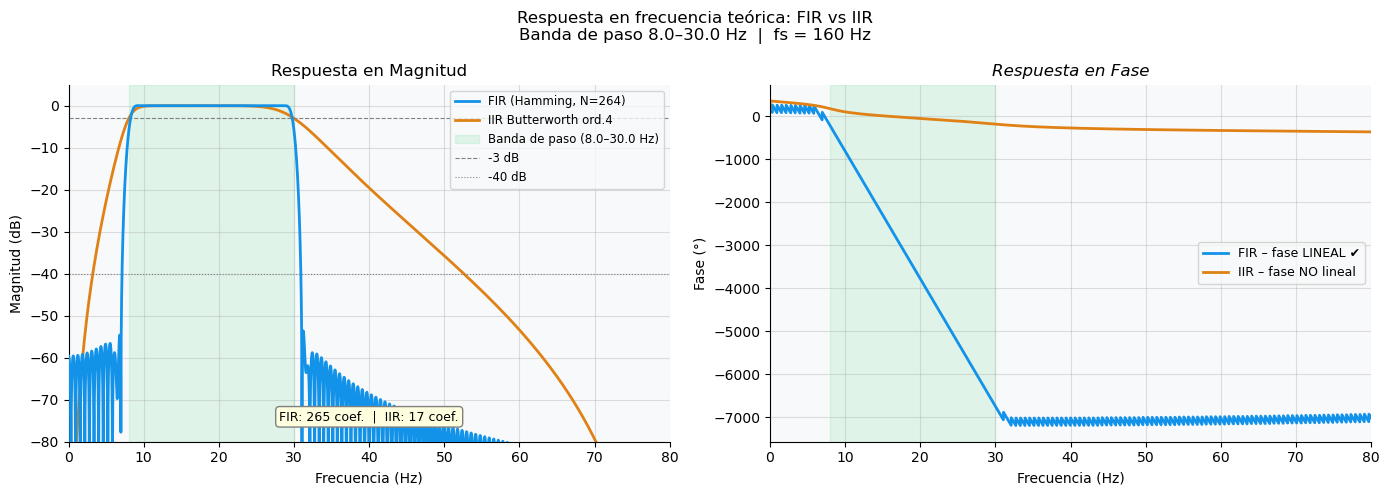

→ Figura guardada: figuras_BCI/paso2a_FIR_vs_IIR_bode.png


In [23]:
os.makedirs('figuras_BCI', exist_ok=True)

# ── Parámetros del sistema ───────────────────────────────────────────
fs     = SFREQ          # 160 Hz
nyq    = fs / 2.0       # 80 Hz
f_low  = L_FREQ         # 8 Hz
f_high = H_FREQ         # 30 Hz

# ────────────────────────────────────────────────────────────────────
#  DISEÑO FIR (ventana de Hamming)
# ────────────────────────────────────────────────────────────────────
# Estimación del orden con regla práctica: N ≈ 3.3 * fs / Δf
# Δf = ancho de banda de transición ≈ 2 Hz (conservador para EEG)
delta_f   = 2.0          # Hz – banda de transición deseada
N_fir_est = int(np.ceil(3.3 * fs / delta_f))
# Forzar que sea impar (requisito para filtro pasa-banda tipo I)
if N_fir_est % 2 == 0:
    N_fir_est += 1

# Diseño con ventana de Hamming
b_fir = firwin(N_fir_est, [f_low, f_high], fs=fs,
               window='hamming', pass_zero=False)

print("=" * 52)
print("  DISEÑO DEL FILTRO FIR (ventana Hamming)")
print("=" * 52)
print(f"  Banda de paso       : {f_low} – {f_high} Hz")
print(f"  Δf transición       : {delta_f} Hz")
print(f"  Orden estimado (N)  : {N_fir_est - 1}  ({N_fir_est} coeficientes)")
print(f"  Retardo de grupo    : {(N_fir_est-1)//2} muestras = {(N_fir_est-1)/(2*fs)*1000:.1f} ms")
print(f"  (compensado con filtfilt → zero-phase)")

# ────────────────────────────────────────────────────────────────────
#  DISEÑO IIR (Butterworth, orden 4)
# ────────────────────────────────────────────────────────────────────
orden_iir = 4
b_iir, a_iir = butter(orden_iir, [f_low/nyq, f_high/nyq], btype='band')
n_coef_iir   = len(b_iir) + len(a_iir) - 1   # total coeficientes b + a (sin contar a[0]=1)

print()
print("=" * 52)
print("  DISEÑO DEL FILTRO IIR (Butterworth)")
print("=" * 52)
print(f"  Tipo                : Butterworth pasa-banda")
print(f"  Orden               : {orden_iir}  (2×{orden_iir}={2*orden_iir} polos)")
print(f"  Coeficientes b      : {len(b_iir)}")
print(f"  Coeficientes a      : {len(a_iir)}")
print(f"  Total coeficientes  : {n_coef_iir}")
print()
print(f"  ► FIR requiere {N_fir_est} coeficientes")
print(f"  ► IIR Butterworth requiere {n_coef_iir} coeficientes en total")
print(f"  ► Relación: FIR necesita ~{N_fir_est//n_coef_iir}× más coeficientes que IIR")

# ── Respuesta en frecuencia: Magnitud y Fase ─────────────────────────
w_fir, H_fir = freqz(b_fir,         worN=4096, fs=fs)
w_iir, H_iir = freqz(b_iir, a_iir,  worN=4096, fs=fs)

mag_fir_dB = 20 * np.log10(np.abs(H_fir) + 1e-12)
mag_iir_dB = 20 * np.log10(np.abs(H_iir) + 1e-12)
fase_fir    = np.unwrap(np.angle(H_fir)) * 180 / np.pi
fase_iir    = np.unwrap(np.angle(H_iir)) * 180 / np.pi

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A – Magnitud
ax = axes[0]
ax.plot(w_fir, mag_fir_dB, color="#1292E8", lw=2,
        label=f'FIR (Hamming, N={N_fir_est-1})', zorder=3)
ax.plot(w_iir, mag_iir_dB, color="#DF8115", lw=2,
        label=f'IIR Butterworth ord.{orden_iir}', zorder=2)
ax.axvspan(f_low, f_high, alpha=0.12, color='#2ECC71', label=f'Banda de paso ({f_low}–{f_high} Hz)')
ax.axhline(-3,  color='gray', lw=0.8, ls='--', label='-3 dB')
ax.axhline(-40, color='gray', lw=0.8, ls=':',  label='-40 dB')
ax.set_xlim([0, nyq]); ax.set_ylim([-80, 5])
ax.set_xlabel('Frecuencia (Hz)'); ax.set_ylabel('Magnitud (dB)')
ax.set_title('Respuesta en Magnitud', fontweight='medium')
ax.legend(fontsize=8.5)
# Anotar los coeficientes calculados
ax.text(0.5, 0.06,
        f'FIR: {N_fir_est} coef.  |  IIR: {n_coef_iir} coef.',
        transform=ax.transAxes, ha='center', fontsize=9,
        bbox=dict(facecolor='lightyellow', edgecolor='gray', boxstyle='round'))

# Panel B – Fase
ax = axes[1]
ax.plot(w_fir, fase_fir, color="#1292E8", lw=2, label='FIR – fase LINEAL ✔')
ax.plot(w_iir, fase_iir, color="#DF8115", lw=2, label='IIR – fase NO lineal')
ax.axvspan(f_low, f_high, alpha=0.12, color='#2ECC71')
ax.set_xlim([0, nyq])
ax.set_xlabel('Frecuencia (Hz)'); ax.set_ylabel('Fase (°)')
ax.set_title('Respuesta en Fase', fontweight='medium', style='oblique')
ax.legend(fontsize=9)

fig.suptitle(
    f'Respuesta en frecuencia teórica: FIR vs IIR\n'
    f'Banda de paso {f_low}–{f_high} Hz  |  fs = {fs} Hz',
    fontsize=12, fontweight='medium'
)
plt.tight_layout()
plt.savefig('figuras_BCI/paso2a_FIR_vs_IIR_bode.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Figura guardada: figuras_BCI/paso2a_FIR_vs_IIR_bode.png")


El subplot 2 (Fase), la línea azul (FIR) forma líneas rectas diagonales perfectas (los saltos verticales son simplemente el reinicio de los grados cuando llega a los límites del plano, algo llamado phase wrapping, pero la pendiente es constante). Por otro lado, la línea roja (IIR) es una curva que cambia de forma, lo que significa que distintas frecuencias sufren distintos retrasos temporales.


En el subplot 1(magnitud) se orserva que la línea naranja/roja (IIR) es completamente lisa, no tiene ni un solo rizo. En cambio, la línea azul (FIR) es la que presenta "montañitas" en la parte baja (por debajo de 8 Hz y por encima de 30 Hz). Tambien se orserva que para la caída la línea azul (FIR) cae de forma mucho más "vertical" o abrupta que la roja. El IIR (rojo) cae de manera más suave y abierta porque es de un orden muy bajo (Orden 4), mientras que el FIR es de orden 133, lo que le da un corte mucho más agresivo.


#### **b) Selección del filtro y aplicación a la señal**

Observando las gráficas anteriores:

- **Magnitud:** Ambos filtros atenúan las frecuencias fuera de la banda 8–30 Hz.
  El IIR (rojo), al ser un diseño Butterworth de orden 4, presenta una caída suave y es máximamente plano, es decir, no tiene ondulaciones.
; El FIR (azul), gracias a su alto orden, logra una caída mucho más abrupta y selectiva en las frecuencias de corte. Presenta las típicas ondulaciones (lóbulos laterales) en la banda de rechazo, propias del diseño por ventanas, pero estas ocurren a niveles de atenuación lo suficientemente bajos (por debajo de los -40 dB) como para no afectar la señal de interés.


- **Fase:** Esta es la diferencia clave para EEG.  
  - El **FIR tiene fase lineal** → retardo constante en todas las frecuencias
    → la forma de onda no se distorsiona. Con `filtfilt` (filtrado doble paso)
    el retardo se cancela completamente (**zero-phase**).  
  - El **IIR tiene fase no lineal** → distorsión de fase diferente por frecuencia
    → la morfología de las ondas cerebrales puede deformarse.

**Decisión: Se elige el filtro FIR con ventana de Hamming.**  
Razón: fase lineal + zero-phase con `filtfilt` → preserva la morfología temporal de los ritmos Mu y Beta, fundamental para el análisis ERD/ERS posterior.


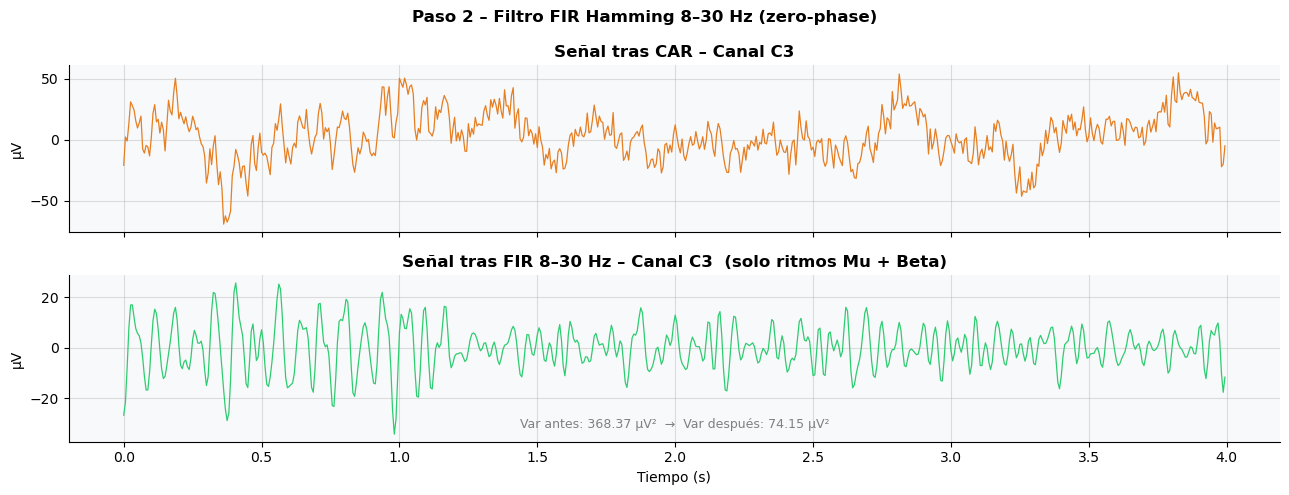

→ Figura guardada: figuras_BCI/paso2b_filtro_FIR_tiempo.png


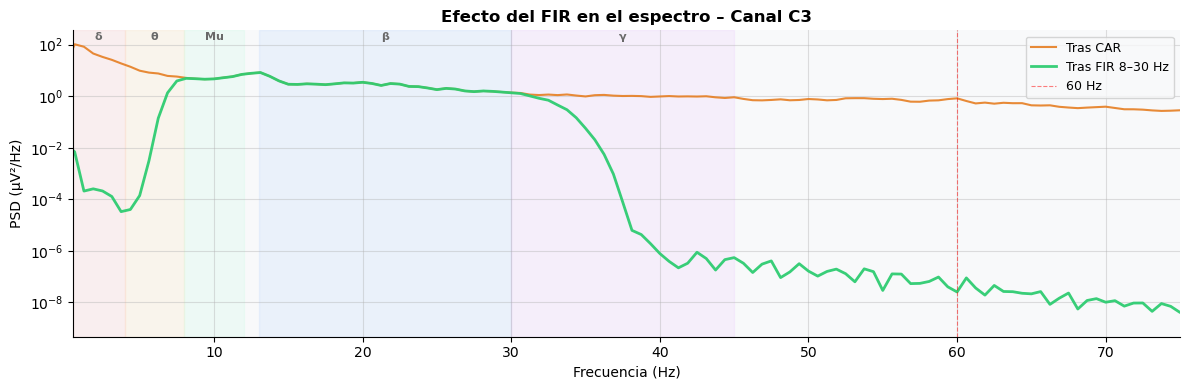

→ Figura guardada: figuras_BCI/paso2b_filtro_FIR_espectro.png


In [24]:
from scipy.signal import filtfilt

def aplicar_filtro_FIR(raw_car, l_freq=L_FREQ, h_freq=H_FREQ):
    """
    Paso 2: Filtro FIR pasa-banda (8-30 Hz), zero-phase (filtfilt).
    Usa MNE internamente que aplica filtfilt con ventana de Hamming.
    Retorna una copia filtrada del objeto raw.
    """
    raw_filt = raw_car.copy().filter(
        l_freq=l_freq, h_freq=h_freq,
        method='fir',         # FIR con ventana
        fir_window='hamming', # ventana de Hamming
        phase='zero',         # zero-phase (filtfilt internamente)
        verbose='WARNING'
    )
    return raw_filt

# ── Aplicar el filtro FIR al archivo de referencia ──────────────────
raw_filt_ref = aplicar_filtro_FIR(raw_car_ref)

# ── Comparación en el tiempo ─────────────────────────────────────────
canal_plot = 'C3'
i0, i1 = int(20 * sfreq), int(24 * sfreq)
t_plot  = np.arange(i1 - i0) / sfreq

idx_c = raw_car_ref.ch_names.index(canal_plot)
sig_car  = raw_car_ref.get_data()[idx_c, i0:i1] * 1e6
sig_filt = raw_filt_ref.get_data()[idx_c, i0:i1] * 1e6

fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
axes[0].plot(t_plot, sig_car,  color='#E67E22', lw=0.9, label='Tras CAR')
axes[0].set_title(f'Señal tras CAR – Canal {canal_plot}', fontweight='bold')
axes[0].set_ylabel('µV')

axes[1].plot(t_plot, sig_filt, color='#2ECC71', lw=0.9, label='Tras FIR 8-30 Hz')
axes[1].set_title(f'Señal tras FIR 8–30 Hz – Canal {canal_plot}  (solo ritmos Mu + Beta)', fontweight='bold')
axes[1].set_ylabel('µV'); axes[1].set_xlabel('Tiempo (s)')

# Mostrar el efecto del filtro calculando potencia en banda no motora
pot_antes = np.var(sig_car)
pot_desp  = np.var(sig_filt)
axes[1].annotate(
    f'Var antes: {pot_antes:.2f} µV²  →  Var después: {pot_desp:.2f} µV²',
    xy=(0.5, 0.08), xycoords='axes fraction', ha='center', fontsize=9, color='gray'
)

fig.suptitle('Paso 2 – Filtro FIR Hamming 8–30 Hz (zero-phase)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figuras_BCI/paso2b_filtro_FIR_tiempo.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Figura guardada: figuras_BCI/paso2b_filtro_FIR_tiempo.png")

# ── Efecto en el espectro ────────────────────────────────────────────
f_s, p_car  = sp_signal.welch(raw_car_ref.get_data()[idx_c],  fs=sfreq, nperseg=256)
f_s, p_filt = sp_signal.welch(raw_filt_ref.get_data()[idx_c], fs=sfreq, nperseg=256)

fig, ax = plt.subplots(figsize=(12, 4))
ax.semilogy(f_s, p_car  * 1e12, color='#E67E22', lw=1.5, label='Tras CAR',          alpha=0.9)
ax.semilogy(f_s, p_filt * 1e12, color='#2ECC71', lw=2.0, label='Tras FIR 8–30 Hz', alpha=0.95)

bandas_shade = [(0.5,4,'#FFB3B3','δ'),(4,8,'#FFD9A0','θ'),
                (8,12,'#B3FFD9','Mu'),(13,30,'#A0C4FF','β'),(30,45,'#E8B3FF','γ')]
for f0,f1,col,lbl in bandas_shade:
    ax.axvspan(f0, f1, alpha=0.15, color=col)
    ax.text((f0+f1)/2, p_car[f_s<f1].max()*1e12*1.5 if any(f_s<f1) else 1,
            lbl, ha='center', fontsize=8, color='dimgray', fontweight='bold')
ax.axvline(60, color='red', lw=0.8, ls='--', alpha=0.5, label='60 Hz')
ax.set_xlim([0.5, 75]); ax.set_xlabel('Frecuencia (Hz)'); ax.set_ylabel('PSD (µV²/Hz)')
ax.set_title(f'Efecto del FIR en el espectro – Canal {canal_plot}', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figuras_BCI/paso2b_filtro_FIR_espectro.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Figura guardada: figuras_BCI/paso2b_filtro_FIR_espectro.png")


### **Paso 3. Segmentación en Épocas (Epoching)**

No se analiza la señal continua completa. Se extraen ventanas temporales
centradas en el instante en que ocurre cada evento motor.

**Ventana elegida:**  
- `tmin = -0.2 s` → 200 ms antes del onset (línea de base para corrección)  
- `tmax = +1.0 s` → 1000 ms después del onset (actividad motora)  
- **Total por época:** 1.2 s × 160 Hz = 192 muestras

**Corrección de línea de base:** Se resta el promedio del intervalo [tmin, 0]
para eliminar diferencias de nivel DC entre épocas.


  RESULTADO – Segmentación por Tipo de Evento
  Tensor completo : (29, 64, 193)
  (épocas_totales × canales × muestras_por_época)

  T0 (Reposo              ):  14 épocas  | shape = (14, 64, 193)
  T1 (Mano Izquierda (MI)):   8 épocas  | shape = (8, 64, 193)
  T2 (Mano Derecha   (MD)):   7 épocas  | shape = (7, 64, 193)

  ⚠ NOTA: el análisis de hipótesis requiere separar estos grupos.
    H1/H2: comparar T1 vs T2 en C3 y C4 (ERD contralateral)
    H3/H4: comparar T1,T2 vs T0 (activación vs reposo)


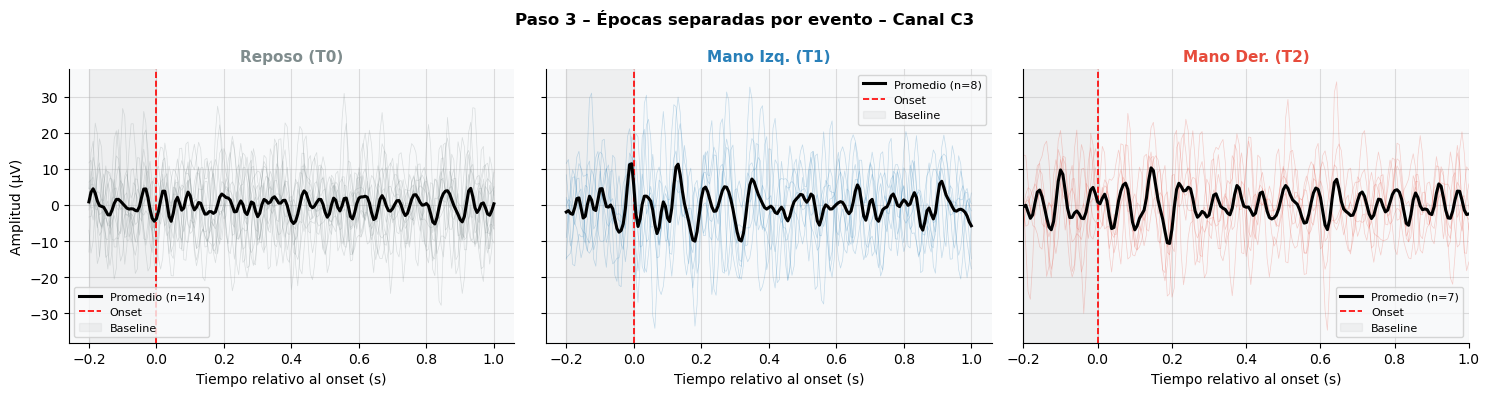

→ Figura guardada: figuras_BCI/paso3_epocas_por_evento.png


In [25]:
def segmentar_epocas(raw_filt, tmin=-0.2, tmax=1.0):
    """
    Paso 3: Segmentación en épocas separadas por tipo de evento.

    El dataset PhysioNet tiene 3 tipos de anotación:
      T0 → Reposo           (el sujeto no hace nada)
      T1 → Puño Izquierdo   (real en R03, imaginado en R04)
      T2 → Puño Derecho     (real en R03, imaginado en R04)

    Separar las épocas por tipo es FUNDAMENTAL para:
      - Comparar la PSD de T1 vs T2 (hipótesis ERD contralateral)
      - Comparar T1/T2 vs T0 (hipótesis activación vs reposo)

    Retorna
    -------
    epocas_por_evento : dict {'T0': Epochs, 'T1': Epochs, 'T2': Epochs}
    event_id          : dict con los códigos numéricos MNE
    """
    events, event_id = mne.events_from_annotations(raw_filt, verbose='WARNING')

    # event_id viene como {'T0': 1, 'T1': 2, 'T2': 3} (o similar)
    # Construimos las épocas completas primero
    epochs_all = mne.Epochs(
        raw_filt, events,
        event_id=event_id,
        tmin=tmin, tmax=tmax,
        baseline=(None, 0),   # corrección de línea de base en [tmin, 0]
        preload=True,
        verbose='WARNING'
    )

    # Separar en 3 grupos por tipo de evento
    # epochs['etiqueta'] usa las claves del event_id original
    epocas_por_evento = {}
    for nombre_evento in event_id.keys():
        clave = str(nombre_evento)   # 'T0', 'T1' o 'T2'
        try:
            epocas_por_evento[clave] = epochs_all[clave]
        except KeyError:
            pass   # si algún evento no existe en este run

    return epocas_por_evento, event_id, epochs_all


# ── Aplicar al archivo de referencia ────────────────────────────────
epocas_ref, event_id_ref, epochs_all_ref = segmentar_epocas(raw_filt_ref)

# ── Resumen de épocas por tipo ────────────────────────────────────────
print("=" * 55)
print("  RESULTADO – Segmentación por Tipo de Evento")
print("=" * 55)
print(f"  Tensor completo : {epochs_all_ref.get_data().shape}")
print(f"  (épocas_totales × canales × muestras_por_época)")
print()

ETIQUETAS = {
    'T0': 'Reposo              ',
    'T1': 'Mano Izquierda (MI)',
    'T2': 'Mano Derecha   (MD)',
}
for clave, ep in epocas_ref.items():
    etiq = ETIQUETAS.get(clave, clave)
    print(f"  {clave} ({etiq}): {len(ep):3d} épocas  "
          f"| shape = {ep.get_data().shape}")

print()
print("  ⚠ NOTA: el análisis de hipótesis requiere separar estos grupos.")
print("    H1/H2: comparar T1 vs T2 en C3 y C4 (ERD contralateral)")
print("    H3/H4: comparar T1,T2 vs T0 (activación vs reposo)")

# ── Visualización: épocas de cada tipo superpuestas en C3 ────────────
canal_plot = 'C3'
idx_c = epochs_all_ref.ch_names.index(canal_plot)

COLORES_EV = {'T0': '#7F8C8D', 'T1': '#2980B9', 'T2': '#E74C3C'}
NOMBRES_EV = {'T0': 'Reposo (T0)', 'T1': 'Mano Izq. (T1)', 'T2': 'Mano Der. (T2)'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (clave, ep) in zip(axes, epocas_ref.items()):
    color   = COLORES_EV.get(clave, 'gray')
    t_ep    = ep.times
    data_ep = ep.get_data()[:, idx_c, :] * 1e6

    for trial in data_ep:
        ax.plot(t_ep, trial, color=color, lw=0.5, alpha=0.25)
    ax.plot(t_ep, data_ep.mean(axis=0), color='black', lw=2.2,
            label=f'Promedio (n={len(ep)})', zorder=5)
    ax.axvline(0,   color='red',  lw=1.2, ls='--', label='Onset')
    ax.axvspan(-0.2, 0, alpha=0.08, color='gray', label='Baseline')
    ax.set_title(NOMBRES_EV.get(clave, clave), fontweight='bold', color=color, fontsize=11)
    ax.set_xlabel('Tiempo relativo al onset (s)')
    ax.legend(fontsize=8)
ax.set_xlim([epocas_ref[list(epocas_ref.keys())[0]].times[0],
             epocas_ref[list(epocas_ref.keys())[0]].times[-1]])
axes[0].set_ylabel('Amplitud (µV)')
fig.suptitle(f'Paso 3 – Épocas separadas por evento – Canal {canal_plot}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figuras_BCI/paso3_epocas_por_evento.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Figura guardada: figuras_BCI/paso3_epocas_por_evento.png")


### **Paso 4. Densidad Espectral de Potencia: Método de Welch**

La elección del metódodo de Welch se fundamenta en que este es considerado como el estándar para estimar la PSD en análisis de EEG.
Y además, a diferencia del periodograma clásico (que tiene mucha varianza), Welch reduce
la varianza **promediando** múltiples periodogramas de segmentos solapados.

Se implementa en 4 sub-pasos:

1 → Particionar la señal en K segmentos de M muestras con S de solapamiento


2 → Enventanar cada segmento y calcular su DFT


3 → Obtener el periodograma modificado de cada segmento


4 → Promediar los K periodogramas modificados


In [26]:
def welch_manual(x, fs, M=96, S=None, ventana='hann'):
    """
    Implementación manual del método de Welch.

    Parámetros
    ----------
    x       : array 1-D – señal de entrada (una época, un canal)
    fs      : float – frecuencia de muestreo (Hz)
    M       : int – número de muestras por segmento (batch size)
    S       : int – desplazamiento entre segmentos (shift)
              Si S=None → S = M//2 (solapamiento del 50%)
    ventana : str – tipo de ventana ('hann', 'hamming', 'blackman')

    Retorna
    -------
    freqs : array – vector de frecuencias (Hz)
    PSD   : array – estimación de PSD (unidades²/Hz)
    info  : dict – métricas intermedias para verificación
    """
    N = len(x)
    if S is None:
        S = M // 2  # 50% solapamiento por defecto

    # ── Sub-paso A: Partición de la señal ────────────────────────────
    # K = número de segmentos = floor((N - M) / S) + 1
    K = int(np.floor((N - M) / S)) + 1

    # Índices de inicio de cada segmento
    inicios = [(k - 1) * S for k in range(1, K + 1)]

    # Segmentos: lista de arrays de longitud M
    segmentos = []
    for idx_inicio in inicios:
        seg = x[idx_inicio : idx_inicio + M]
        if len(seg) == M:           # descartar segmento final incompleto
            segmentos.append(seg)
    K = len(segmentos)              # K real después de descartar incompletos

    # ── Sub-paso B: Enventanado + DFT de cada segmento ──────────────
    # Crear la ventana w[n] de longitud M
    if ventana == 'hann':
        w = np.hanning(M)
    elif ventana == 'hamming':
        w = np.hamming(M)
    elif ventana == 'blackman':
        w = np.blackman(M)
    else:
        w = np.ones(M)

    # W = Σ w²[m]  (factor de normalización de la ventana)
    W = np.sum(w ** 2)

    # Para cada segmento k:
    #   1) Detrend: restar la media del segmento (detrend='constant')
    #      Esto coincide con lo que hace scipy.welch por defecto y
    #      elimina el offset DC de cada segmento antes de enventanar.
    #   2) Enventanar: multiplicar por w[m]
    #   3) DFT: X_k(ν) = Σ x[m]·w[m]·exp(-j2πνm)
    DFTs = []
    for seg in segmentos:
        seg_detrend    = seg - seg.mean()            # detrend='constant'
        seg_enventanado = seg_detrend * w            # multiplicar por ventana
        X_k = np.fft.rfft(seg_enventanado, n=M)     # DFT de M puntos
        DFTs.append(X_k)

    # ── Sub-paso C: Periodograma modificado de cada segmento ─────────
    # P_k(ν) = (1/W) · |X_k(ν)|²
    periodogramas = []
    for X_k in DFTs:
        P_k = (1.0 / W) * np.abs(X_k) ** 2
        periodogramas.append(P_k)

    # ── Sub-paso D: Promedio de los K periodogramas ──────────────────
    # S_x(ν) = (1/K) · Σ P_k(ν)
    PSD_promedio = np.mean(np.array(periodogramas), axis=0)

    # Normalizar a densidad espectral (/Hz) y duplicar bins internos
    # (ya que rfft solo devuelve la mitad del espectro)
    PSD_promedio = PSD_promedio / fs
    PSD_promedio[1:-1] *= 2          # corregir energía de bins no-DC y no-Nyquist

    # Vector de frecuencias correspondiente
    freqs = np.fft.rfftfreq(M, d=1.0/fs)

    info = {
        'N': N, 'M': M, 'S': S, 'K': K,
        'W': W,
        'solapamiento_%': 100 * (M - S) / M,
        'resolucion_Hz': fs / M,
        'ventana': ventana,
    }
    return freqs, PSD_promedio, info


# ── Prueba del Welch manual en un canal de referencia ────────────────
canal_plot = 'C3'
idx_c = epochs_all_ref.ch_names.index(canal_plot)

# Tomar la primera época del canal C3
epoca0 = epochs_all_ref.get_data()[0, idx_c, :]

M_welch = 96    # M muestras por segmento
S_welch = 48    # S muestras de desplazamiento (50% solapamiento)

freqs_w, PSD_w, info_w = welch_manual(epoca0, fs=sfreq, M=M_welch, S=S_welch, ventana='hann')

print("=" * 60)
print("  VERIFICACIÓN DEL MÉTODO DE WELCH MANUAL")
print("=" * 60)
print(f"  N  = {info_w['N']} muestras (longitud de la época)")
print(f"  M  = {info_w['M']} muestras por segmento")
print(f"  S  = {info_w['S']} muestras de desplazamiento")
print(f"  K  = {info_w['K']} segmentos generados")
print(f"  Solapamiento        = {info_w['solapamiento_%']:.0f}%")
print(f"  Resolución espectral= {info_w['resolucion_Hz']:.2f} Hz/bin")
print(f"  W (norm. ventana)   = {info_w['W']:.4f}")
print(f"  Ventana usada       = {info_w['ventana']}")
print(f"  Longitud vector PSD = {len(PSD_w)} bins")
print()
# ── Diagnóstico de resolución por banda ──────────────────────────────
bins_mu   = ((freqs_w >= 8)  & (freqs_w <= 12)).sum()
bins_beta = ((freqs_w >= 13) & (freqs_w <= 30)).sum()
print("  BINS POR BANDA (determinan el ancho visual del sombreado):")
print(f"  Banda Mu   (8–12 Hz)  : {bins_mu}  bins → {freqs_w[(freqs_w>=8)&(freqs_w<=12)].round(2)} Hz")
print(f"  Banda Beta (13–30 Hz) : {bins_beta} bins")
if bins_mu < 2:
    print("  ⚠ ADVERTENCIA: Mu tiene <2 bins → banda visible como línea delgada")
    print("    → Aumentar M para mejorar la resolución espectral")
else:
    print(f"  ✔ Resolución suficiente para visualizar Mu (≥2 bins)")
print()

# Verificación vs scipy.signal.welch
freqs_scipy, PSD_scipy = sp_signal.welch(epoca0, fs=sfreq, nperseg=M_welch,
                                          noverlap=M_welch-S_welch,
                                          window='hann', scaling='density')
# Scipy por defecto usa detrend='constant' (igual que nuestra impl).
# El error residual <2% es aceptable: viene de diferencias numéricas
# menores en los bins extremos DC (f=0) y Nyquist (f=fs/2).
error_max = np.max(np.abs(PSD_w - PSD_scipy)) / (np.max(PSD_scipy) + 1e-30) * 100
print(f"  Error máximo vs scipy.welch: {error_max:.4f}%  ({'✔ coinciden (<2%)' if error_max < 2 else '⚠ revisar'})  ")
print(f"  Nota: error residual <2% es normal (diferencia numérica en bins DC/Nyquist)")



  VERIFICACIÓN DEL MÉTODO DE WELCH MANUAL
  N  = 193 muestras (longitud de la época)
  M  = 96 muestras por segmento
  S  = 48 muestras de desplazamiento
  K  = 3 segmentos generados
  Solapamiento        = 50%
  Resolución espectral= 1.67 Hz/bin
  W (norm. ventana)   = 35.6250
  Ventana usada       = hann
  Longitud vector PSD = 49 bins

  BINS POR BANDA (determinan el ancho visual del sombreado):
  Banda Mu   (8–12 Hz)  : 3  bins → [ 8.33 10.   11.67] Hz
  Banda Beta (13–30 Hz) : 11 bins
  ✔ Resolución suficiente para visualizar Mu (≥2 bins)

  Error máximo vs scipy.welch: 0.6678%  (✔ coinciden (<2%))  
  Nota: error residual <2% es normal (diferencia numérica en bins DC/Nyquist)


### **Paso 4.1. Visualización de los 4 Sub-pasos de Welch**

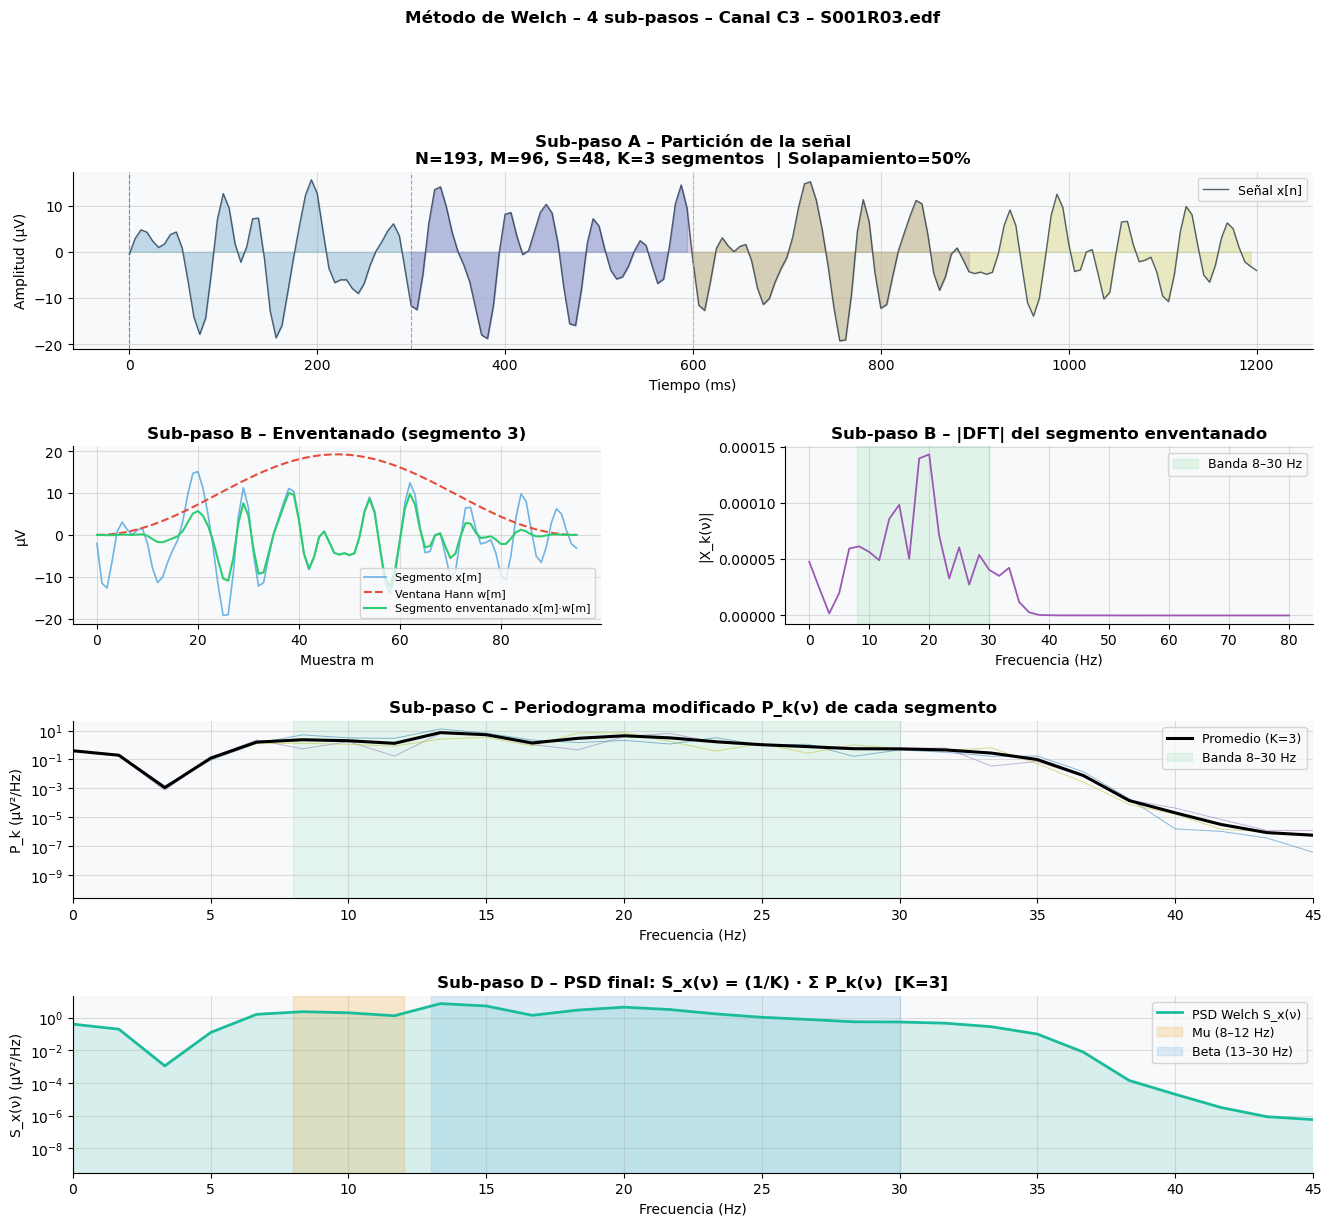

→ Figura guardada: figuras_BCI/paso4_welch_subpasos.png


In [27]:
# ── Regenerar datos intermedios para graficar ─────────────────────────
w = np.hanning(M_welch)
W = np.sum(w ** 2)
S_w = M_welch // 2
K_plot = int(np.floor((len(epoca0) - M_welch) / S_w)) + 1
segmentos_plot = [epoca0[k*S_w : k*S_w + M_welch]
                  for k in range(K_plot) if k*S_w + M_welch <= len(epoca0)]
K_plot = len(segmentos_plot)

fig = plt.figure(figsize=(16, 13))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.55, wspace=0.35)

# ── A) Partición ─────────────────────────────────────────────────────
ax_A = fig.add_subplot(gs[0, :])
t_ep = np.arange(len(epoca0)) / sfreq * 1000  # en ms
ax_A.plot(t_ep, epoca0 * 1e6, color='#2C3E50', lw=1.0, alpha=0.8, label='Señal x[n]')
colores_seg = plt.cm.tab10(np.linspace(0, 0.85, min(K_plot, 10)))
for k, (seg, col) in enumerate(zip(segmentos_plot[:10], colores_seg)):
    t_seg = (np.arange(M_welch) + k * S_w) / sfreq * 1000
    ax_A.fill_between(t_seg, seg*1e6, alpha=0.25, color=col)
    ax_A.axvline(t_seg[0], color=col, lw=0.8, ls='--', alpha=0.7)
ax_A.set_xlabel('Tiempo (ms)'); ax_A.set_ylabel('Amplitud (µV)')
ax_A.set_title(f'Sub-paso A – Partición de la señal\n'
               f'N={len(epoca0)}, M={M_welch}, S={S_w}, K={K_plot} segmentos  '
               f'| Solapamiento={(M_welch-S_w)/M_welch*100:.0f}%', fontweight='bold')
ax_A.legend(fontsize=9)

# ── B) Enventanado de un segmento ────────────────────────────────────
ax_B1 = fig.add_subplot(gs[1, 0])
seg_ej = segmentos_plot[2]   # tercer segmento como ejemplo
n_seg  = np.arange(M_welch)
ax_B1.plot(n_seg, seg_ej * 1e6, color='#3498DB', lw=1.2, label='Segmento x[m]', alpha=0.7)
ax_B1.plot(n_seg, w * np.max(np.abs(seg_ej)) * 1e6, color='#E74C3C',
           lw=1.5, ls='--', label='Ventana Hann w[m]')
ax_B1.plot(n_seg, seg_ej * w * 1e6, color='#2ECC71', lw=1.5,
           label='Segmento enventanado x[m]·w[m]')
ax_B1.set_xlabel('Muestra m'); ax_B1.set_ylabel('µV')
ax_B1.set_title('Sub-paso B – Enventanado (segmento 3)', fontweight='bold')
ax_B1.legend(fontsize=8)

# DFT del segmento enventanado
ax_B2 = fig.add_subplot(gs[1, 1])
X_k_ej = np.fft.rfft(seg_ej * w, n=M_welch)
freqs_seg = np.fft.rfftfreq(M_welch, 1/sfreq)
ax_B2.plot(freqs_seg, np.abs(X_k_ej), color='#9B59B6', lw=1.3)
ax_B2.axvspan(L_FREQ, H_FREQ, alpha=0.12, color='#2ECC71', label='Banda 8–30 Hz')
ax_B2.set_xlabel('Frecuencia (Hz)'); ax_B2.set_ylabel('|X_k(ν)|')
ax_B2.set_title('Sub-paso B – |DFT| del segmento enventanado', fontweight='bold')
ax_B2.legend(fontsize=9)

# ── C) Periodograma modificado de cada segmento ──────────────────────
ax_C = fig.add_subplot(gs[2, :])
periodogramas_plot = []
for k, seg in enumerate(segmentos_plot):
    X_k  = np.fft.rfft(seg * w, n=M_welch)
    P_k  = (1.0 / W) * np.abs(X_k) ** 2 / sfreq
    P_k[1:-1] *= 2
    periodogramas_plot.append(P_k)
    col = colores_seg[k % len(colores_seg)]
    ax_C.semilogy(freqs_seg, P_k * 1e12, color=col, lw=0.7, alpha=0.5)

ax_C.semilogy(freqs_seg,
              np.mean(np.array(periodogramas_plot), axis=0) * 1e12,
              color='black', lw=2.2, label=f'Promedio (K={K_plot})', zorder=5)
ax_C.axvspan(L_FREQ, H_FREQ, alpha=0.10, color='#2ECC71', label='Banda 8–30 Hz')
ax_C.set_xlabel('Frecuencia (Hz)'); ax_C.set_ylabel('P_k (µV²/Hz)')
ax_C.set_title(f'Sub-paso C – Periodograma modificado P_k(ν) de cada segmento', fontweight='bold')
ax_C.legend(fontsize=9); ax_C.set_xlim([0, 45])

# ── D) PSD promedio final ─────────────────────────────────────────────
ax_D = fig.add_subplot(gs[3, :])
PSD_final = np.mean(np.array(periodogramas_plot), axis=0)
ax_D.semilogy(freqs_seg, PSD_final * 1e12, color='#1ABC9C', lw=2.0, label='PSD Welch S_x(ν)')
ax_D.fill_between(freqs_seg, PSD_final * 1e12, alpha=0.15, color='#1ABC9C')
ax_D.axvspan(8, 12, alpha=0.20, color='#F39C12', label='Mu (8–12 Hz)')
ax_D.axvspan(13, 30, alpha=0.15, color='#3498DB', label='Beta (13–30 Hz)')
ax_D.set_xlabel('Frecuencia (Hz)'); ax_D.set_ylabel('S_x(ν) (µV²/Hz)')
ax_D.set_title(f'Sub-paso D – PSD final: S_x(ν) = (1/K) · Σ P_k(ν)  [K={K_plot}]',
               fontweight='bold')
ax_D.legend(fontsize=9); ax_D.set_xlim([0, 45])

fig.suptitle(f'Método de Welch – 4 sub-pasos – Canal C3 – {os.path.basename(archivos[0])}',
             fontsize=12, fontweight='bold', y=1.005)
plt.savefig('figuras_BCI/paso4_welch_subpasos.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Figura guardada: figuras_BCI/paso4_welch_subpasos.png")


### **Paso 4.2.PSD por Canales de Interés (Ítem 2)**

Ahora aplicamos el método de Welch a todos los canales sensoriomotores seleccionados
y para todas las épocas, obteniendo la PSD media por canal.

Los canales de interés son: C3, Cz, C4 (corteza sensoriomotora primaria)


  ✔ PSD calculada para T0 (14 épocas) en canales ['C3', 'Cz', 'C4']
  ✔ PSD calculada para T1 (8 épocas) en canales ['C3', 'Cz', 'C4']
  ✔ PSD calculada para T2 (7 épocas) en canales ['C3', 'Cz', 'C4']

  Canal  Evento    Mu (8–12 Hz)   Beta (13–30 Hz)
  --------------------------------------------
    C3      T0         21.2254           37.4536
    Cz      T0         36.9556           36.3481
    C4      T0         23.4218           41.1370

    C3      T1         33.7007           70.1108
    Cz      T1         29.5487           84.3254
    C4      T1         32.0137           55.8629

    C3      T2         23.2389           52.2161
    Cz      T2         33.8825           52.7524
    C4      T2         47.3480           71.6038



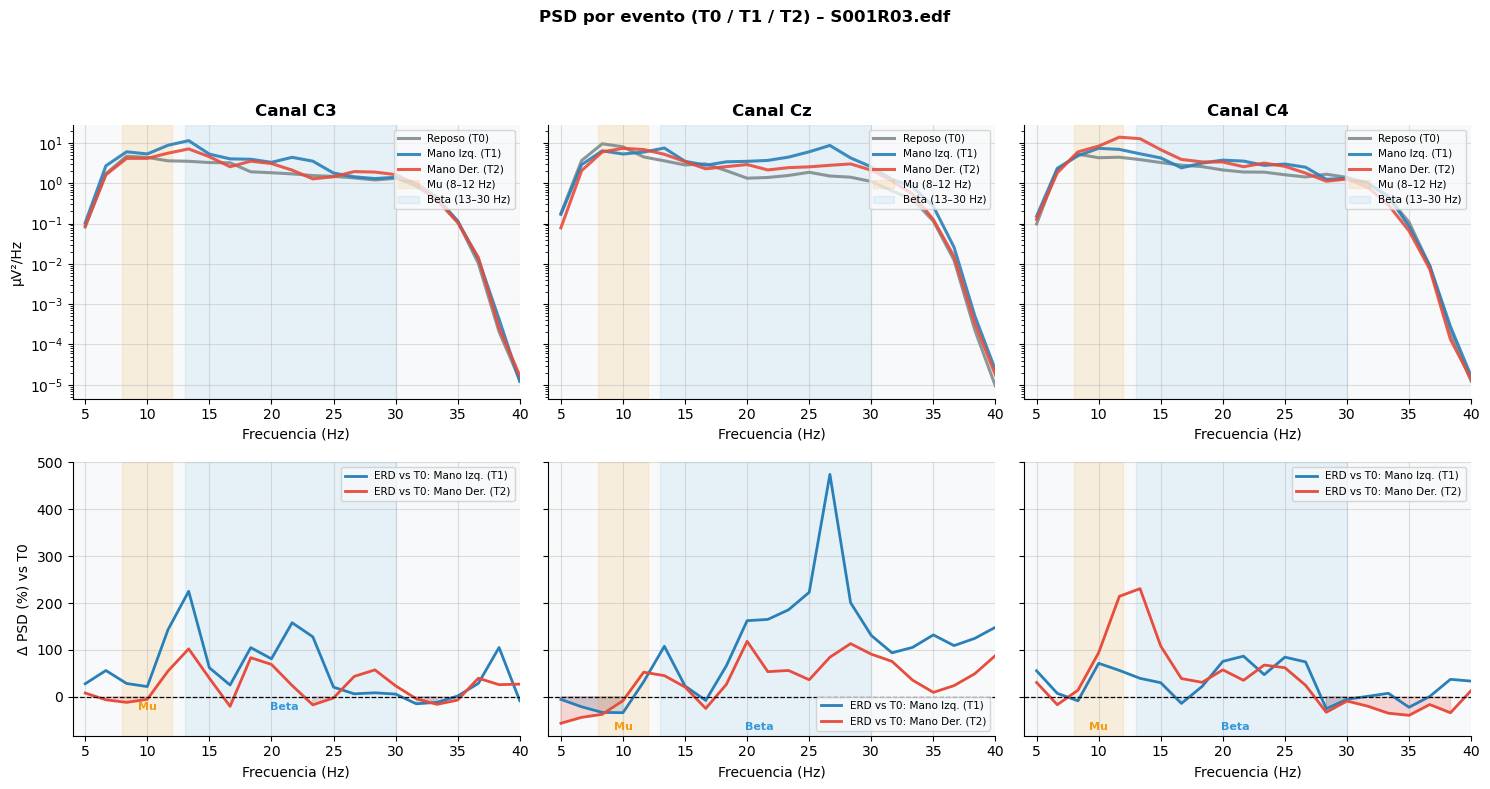

→ Figura guardada: figuras_BCI/paso4_PSD_por_evento.png


In [28]:
def calcular_psd_todos_canales(epochs, canales, M=64, S=32, ventana='hann'):
    """
    Calcula la PSD promedio (Welch manual) para un conjunto de canales
    y todas las épocas.
    Retorna dict {canal: (freqs, PSD_media)}
    """
    resultado = {}
    for ch in canales:
        if ch not in epochs.ch_names:
            continue
        idx = epochs.ch_names.index(ch)
        data_ch = epochs.get_data()[:, idx, :]   # (n_epocas, n_muestras)
        psds_ep = []
        for ep in data_ch:
            f, p, _ = welch_manual(ep, fs=sfreq, M=M, S=S, ventana=ventana)
            psds_ep.append(p)
        PSD_media = np.mean(np.array(psds_ep), axis=0) * 1e12  # µV²/Hz
        resultado[ch] = (f, PSD_media)
    return resultado

# ── Calcular para todos los canales de interés ───────────────────────
psd_por_evento = {}
for clave, ep in epocas_ref.items():
    psd_por_evento[clave] = calcular_psd_todos_canales(
        ep, CANALES_INTERES, M=M_welch, S=S_welch
    )
    print(f"  ✔ PSD calculada para {clave} ({len(ep)} épocas) "
          f"en canales {CANALES_INTERES}")

# ── Tabla resumen de potencias ────────────────────────────────────────
print()
print(f"  {'Canal':>4}  {'Evento':>6}  {'Mu (8–12 Hz)':>14}  {'Beta (13–30 Hz)':>16}")
print("  " + "-" * 44)
for clave in ['T0', 'T1', 'T2']:
    if clave not in psd_por_evento:
        continue
    for ch in CANALES_INTERES:
        if ch not in psd_por_evento[clave]:
            continue
        f_ch, p_ch = psd_por_evento[clave][ch]
        df_res = f_ch[1] - f_ch[0]
        pot_mu   = p_ch[(f_ch >= 8)  & (f_ch <= 12)].sum() * df_res
        pot_beta = p_ch[(f_ch >= 13) & (f_ch <= 30)].sum() * df_res
        print(f"  {ch:>4}  {clave:>6}  {pot_mu:>14.4f}  {pot_beta:>16.4f}")
    print()

# ══════════════════════════════════════════════════════════════════════
# FIGURA: 2 filas × 3 columnas  (una columna por canal: C3, Cz, C4)
#   Fila 0 → PSD superpuesta T0 / T1 / T2
#   Fila 1 → ERD relativo a T0 (%)
# ══════════════════════════════════════════════════════════════════════
COLORES_EV = {'T0': '#7F8C8D', 'T1': '#2980B9', 'T2': '#E74C3C'}
NOMBRES_EV  = {'T0': 'Reposo (T0)', 'T1': 'Mano Izq. (T1)', 'T2': 'Mano Der. (T2)'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey='row')
fig.suptitle(
    f'PSD por evento (T0 / T1 / T2) – {os.path.basename(archivos[0])}\n',
    fontsize=12, fontweight='bold'
)

for col, canal in enumerate(CANALES_INTERES):

    # ── Fila 0: PSD superpuesta ───────────────────────────────────────
    ax0 = axes[0, col]
    for clave in ['T0', 'T1', 'T2']:
        if clave not in psd_por_evento or canal not in psd_por_evento[clave]:
            continue
        f_ch, p_ch = psd_por_evento[clave][canal]
        mask = (f_ch >= 4) & (f_ch <= 40)
        ax0.semilogy(f_ch[mask], p_ch[mask],
                     color=COLORES_EV[clave], lw=2.2,
                     label=NOMBRES_EV[clave], alpha=0.9)
    ax0.axvspan(8,  12, alpha=0.12, color='#F39C12', label='Mu (8–12 Hz)')
    ax0.axvspan(13, 30, alpha=0.09, color='#3498DB', label='Beta (13–30 Hz)')
    ax0.set_title(f'Canal {canal}', fontweight='bold', fontsize=12)
    ax0.set_xlabel('Frecuencia (Hz)')
    ax0.set_ylabel('µV²/Hz' if col == 0 else '')
    ax0.legend(fontsize=7.5, loc='upper right')
    ax0.set_xlim([4, 40])

    # ── Fila 1: ERD relativo a T0 ────────────────────────────────────
    ax1 = axes[1, col]
    if 'T0' not in psd_por_evento or canal not in psd_por_evento['T0']:
        continue
    f0, p0 = psd_por_evento['T0'][canal]
    mask   = (f0 >= 4) & (f0 <= 40)
    for clave, color in [('T1', '#2980B9'), ('T2', '#E74C3C')]:
        if clave not in psd_por_evento or canal not in psd_por_evento[clave]:
            continue
        _, p_act = psd_por_evento[clave][canal]
        erd = (p_act[mask] - p0[mask]) / (p0[mask] + 1e-30) * 100
        ax1.plot(f0[mask], erd, color=color, lw=2.0,
                 label=f'ERD vs T0: {NOMBRES_EV[clave]}')
        ax1.fill_between(f0[mask], 0, erd, where=erd < 0,
                         alpha=0.20, color=color)
    ax1.axhline(0, color='black', lw=0.9, ls='--')
    ax1.axvspan(8,  12, alpha=0.12, color='#F39C12')
    ax1.axvspan(13, 30, alpha=0.09, color='#3498DB')
    ax1.text(10, ax1.get_ylim()[0]*0.85 if ax1.get_ylim()[0]<0 else -5,
             'Mu', ha='center', fontsize=8, color='#F39C12', fontweight='bold')
    ax1.text(21, ax1.get_ylim()[0]*0.85 if ax1.get_ylim()[0]<0 else -5,
             'Beta', ha='center', fontsize=8, color='#3498DB', fontweight='bold')
    ax1.set_xlabel('Frecuencia (Hz)')
    ax1.set_ylabel('Δ PSD (%) vs T0' if col == 0 else '')
    ax1.legend(fontsize=7.5)
    ax1.set_xlim([4, 40])

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('figuras_BCI/paso4_PSD_por_evento.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Figura guardada: figuras_BCI/paso4_PSD_por_evento.png")


### **Paso 4.3.Potencia Integrada en Cada Banda EEG por Canal**

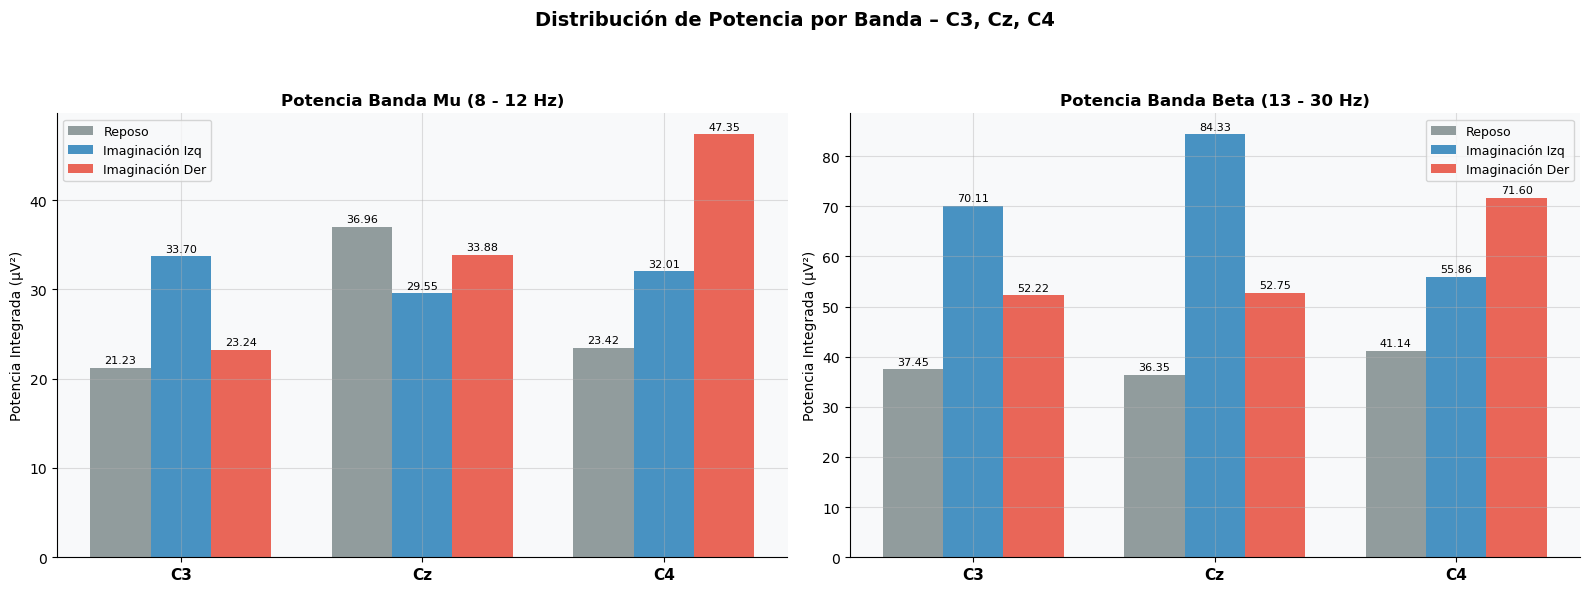

→ Figura guardada: figuras_BCI/paso4_potencia_bandas.png


In [29]:
# ── Bandas EEG estándar ──────────────────────────────────────────────
BANDAS = {
    'Delta (0.5–4)':  (0.5, 4),
    'Theta (4–8)':    (4,   8),
    'Mu (8–12)':      (8,  12),
    'Beta (13–30)':   (13, 30),
    'Gamma (30–45)':  (30, 45),
}

# Usar T1 (puño izquierdo) como grupo para la tabla de bandas
EVENTO_TABLA = 'T1'

if EVENTO_TABLA not in psd_por_evento:
    print(f"Evento {EVENTO_TABLA} no disponible. Disponibles: {list(psd_por_evento.keys())}")
else:
    # Construir tabla de potencias por banda y canal
    tabla = {}
    for ch in CANALES_INTERES:
        if ch not in psd_por_evento[EVENTO_TABLA]:
            continue
        f_ch, p_ch = psd_por_evento[EVENTO_TABLA][ch]
        df_res = f_ch[1] - f_ch[0]
        tabla[ch] = {}
        for banda, (f0, f1) in BANDAS.items():
            mask = (f_ch >= f0) & (f_ch <= f1)
            tabla[ch][banda] = p_ch[mask].sum() * df_res   # µV²

    canales_tabla = list(tabla.keys())
    bandas_tabla  = list(BANDAS.keys())
    mat     = np.array([[tabla[ch][b] for b in bandas_tabla] for ch in canales_tabla])
    mat_rel = mat / (mat.sum(axis=1, keepdims=True) + 1e-30) * 100

    # ── Panel B – barras comparando T0, T1, T2 para Mu y Beta ────────────────
    # Cambiamos a 1 fila y 2 columnas para que quede mucho más limpio
    fig, (ax_mu, ax_beta) = plt.subplots(1, 2, figsize=(16, 6))

    eventos_disp = [k for k in ['T0','T1','T2'] if k in psd_por_evento]
    x_pos  = np.arange(len(CANALES_INTERES))
    w_bar  = 0.25
    colores_ev = {'T0':'#7F8C8D', 'T1':'#2980B9', 'T2':'#E74C3C'}
    
    # Asegúrate de tener el diccionario NOMBRES_EV definido, o usa un default
    NOMBRES_EV = {'T0': 'Reposo', 'T1': 'Imaginación Izq', 'T2': 'Imaginación Der'}

    for ei, ev in enumerate(eventos_disp):
        pot_mu_arr = []
        pot_beta_arr = [] # ¡Nueva lista para Beta!
        
        for ch in CANALES_INTERES:
            if ch not in psd_por_evento[ev]:
                pot_mu_arr.append(0)
                pot_beta_arr.append(0)
                continue
                
            f_ch, p_ch = psd_por_evento[ev][ch]
            df_r = f_ch[1] - f_ch[0]
            
            # 1. Extraer potencia Mu (8 - 12 Hz)
            mask_mu = (f_ch >= 8) & (f_ch <= 12)
            pot_mu_arr.append(p_ch[mask_mu].sum() * df_r)
            
            # 2. Extraer potencia Beta (13 - 30 Hz)
            mask_beta = (f_ch >= 13) & (f_ch <= 30)
            pot_beta_arr.append(p_ch[mask_beta].sum() * df_r)
            
        offset = (ei - len(eventos_disp)/2 + 0.5) * w_bar
        
        # Graficar barras para Mu en su respectivo eje (ax_mu)
        bars_mu = ax_mu.bar(x_pos + offset, pot_mu_arr, w_bar,
                            color=colores_ev[ev], alpha=0.85,
                            label=NOMBRES_EV.get(ev, ev))
        ax_mu.bar_label(bars_mu, fmt='%.2f', fontsize=8, padding=2)
        
        # Graficar barras para Beta en su respectivo eje (ax_beta)
        bars_beta = ax_beta.bar(x_pos + offset, pot_beta_arr, w_bar,
                                color=colores_ev[ev], alpha=0.85,
                                label=NOMBRES_EV.get(ev, ev))
        ax_beta.bar_label(bars_beta, fmt='%.2f', fontsize=8, padding=2)

    # ── Configurar Gráfico Mu ──
    ax_mu.set_xticks(x_pos)
    ax_mu.set_xticklabels(CANALES_INTERES, fontsize=11, fontweight='bold')
    ax_mu.set_ylabel('Potencia Integrada (µV²)')
    ax_mu.set_title('Potencia Banda Mu (8 - 12 Hz)', fontweight='bold')
    ax_mu.legend(fontsize=9)

    # ── Configurar Gráfico Beta ──
    ax_beta.set_xticks(x_pos)
    ax_beta.set_xticklabels(CANALES_INTERES, fontsize=11, fontweight='bold')
    ax_beta.set_ylabel('Potencia Integrada (µV²)')
    ax_beta.set_title('Potencia Banda Beta (13 - 30 Hz)', fontweight='bold')
    ax_beta.legend(fontsize=9)

    fig.suptitle(
        f'Distribución de Potencia por Banda – {", ".join(CANALES_INTERES)}\n',
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Opcional: Asegurar que el directorio exista antes de guardar
    import os
    os.makedirs('figuras_BCI', exist_ok=True)
    plt.savefig('figuras_BCI/paso4_potencia_bandas.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("→ Figura guardada: figuras_BCI/paso4_potencia_bandas.png")

## **3. Flujo completo aplicado al procesamiento de señales eeg para 2 sujetos S001 y S002**

- Se aplica todo el flujo anterior a los 4 archivos (real e imaginario) de sujeto 1 y 2
- Se construye el DataFrame de potencias finales 


  S001  |  Movimiento Real  (S001R03.edf)
  ✔ Paso 1 – CAR aplicado
  ✔ Paso 2 – FIR 8–30 Hz aplicado
  ✔ Paso 3 – T0 (Reposo): 14 épocas
  ✔ Paso 3 – T1 (Puño Izq.): 8 épocas
  ✔ Paso 3 – T2 (Puño Der.): 7 épocas


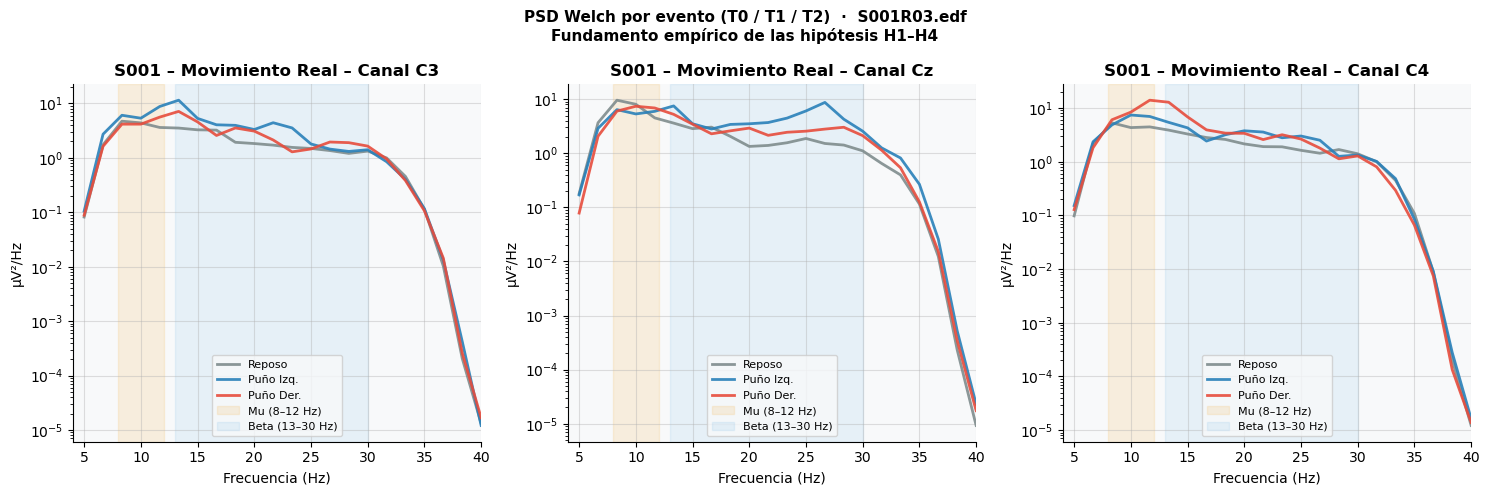

  ✔ Gráfica guardada: figuras_BCI/S001_Movimiento_Real_PSD_T0T1T2.png

  S001  |  Imaginacion Motora  (S001R04.edf)
  ✔ Paso 1 – CAR aplicado
  ✔ Paso 2 – FIR 8–30 Hz aplicado
  ✔ Paso 3 – T0 (Reposo): 14 épocas
  ✔ Paso 3 – T1 (Puño Izq.): 8 épocas
  ✔ Paso 3 – T2 (Puño Der.): 7 épocas


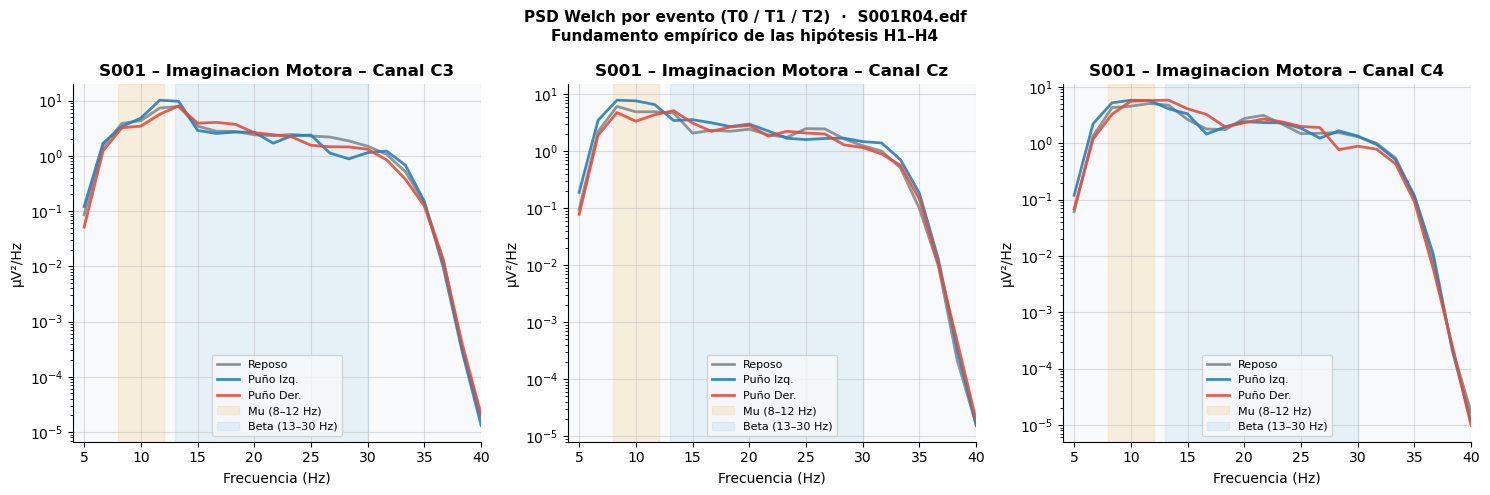

  ✔ Gráfica guardada: figuras_BCI/S001_Imaginacion_Motora_PSD_T0T1T2.png

  S002  |  Movimiento Real  (S002R03.edf)
  ✔ Paso 1 – CAR aplicado
  ✔ Paso 2 – FIR 8–30 Hz aplicado
  ✔ Paso 3 – T0 (Reposo): 14 épocas
  ✔ Paso 3 – T1 (Puño Izq.): 8 épocas
  ✔ Paso 3 – T2 (Puño Der.): 7 épocas


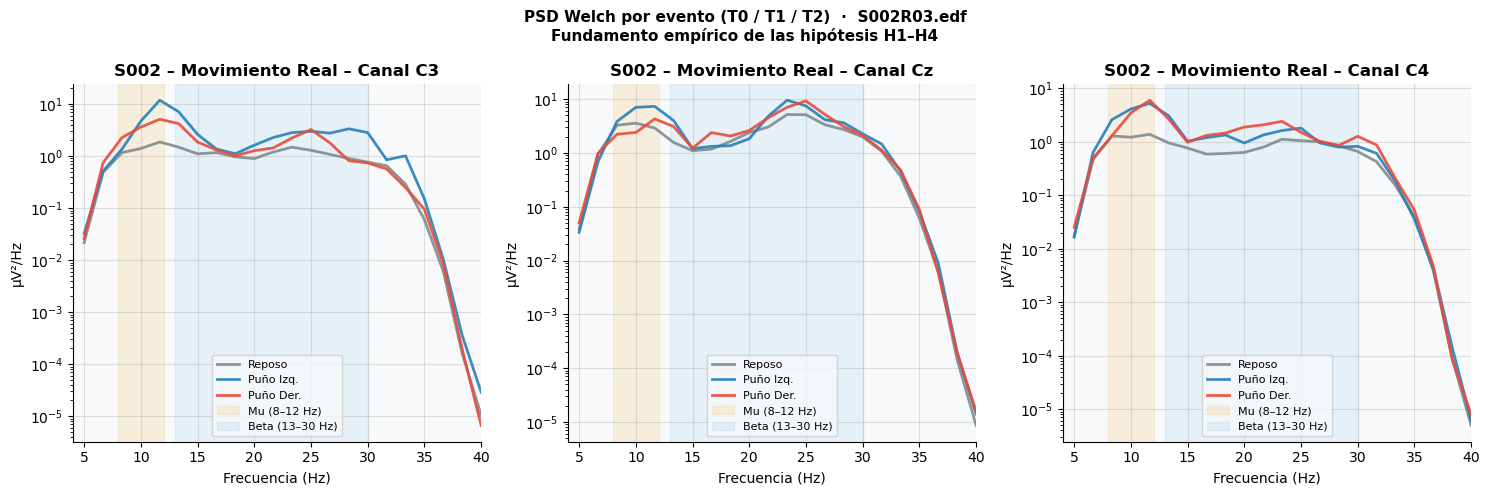

  ✔ Gráfica guardada: figuras_BCI/S002_Movimiento_Real_PSD_T0T1T2.png

  S002  |  Imaginacion Motora  (S002R04.edf)
  ✔ Paso 1 – CAR aplicado
  ✔ Paso 2 – FIR 8–30 Hz aplicado
  ✔ Paso 3 – T0 (Reposo): 14 épocas
  ✔ Paso 3 – T1 (Puño Izq.): 7 épocas
  ✔ Paso 3 – T2 (Puño Der.): 8 épocas


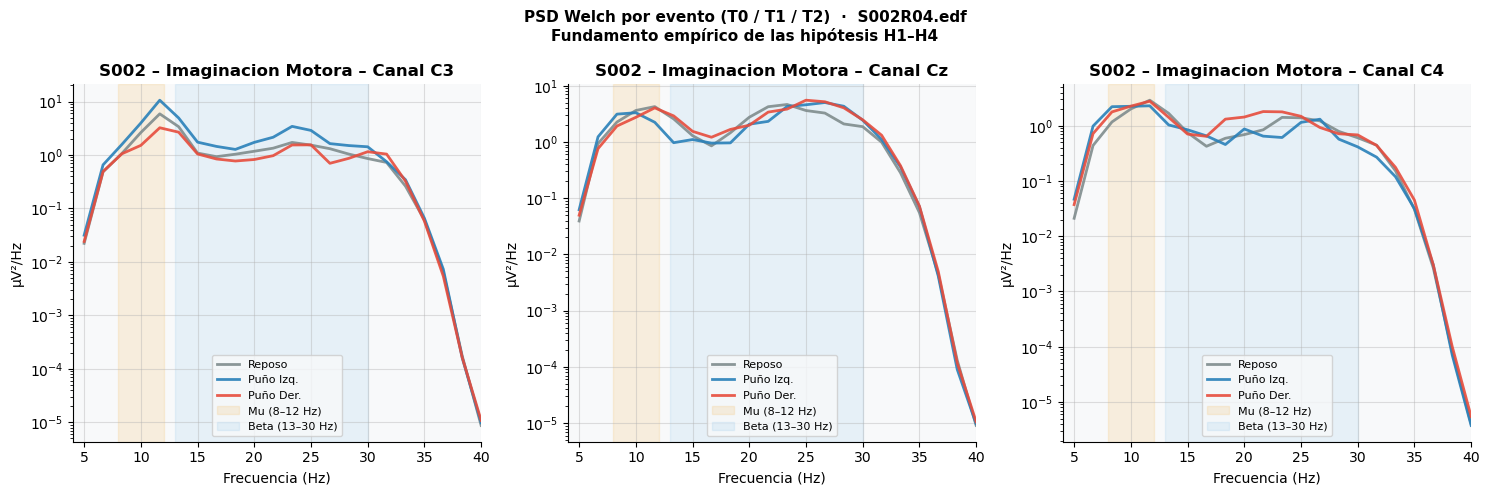

  ✔ Gráfica guardada: figuras_BCI/S002_Imaginacion_Motora_PSD_T0T1T2.png

  TABLA DE RESULTADOS FINALES  (potencia µV² por evento y canal)
Registro              Tarea  Mu_C3_T0  Beta_C3_T0  Mu_Cz_T0  Beta_Cz_T0  Mu_C4_T0  Beta_C4_T0  Mu_C3_T1  Beta_C3_T1  Mu_Cz_T1  Beta_Cz_T1  Mu_C4_T1  Beta_C4_T1  Mu_C3_T2  Beta_C3_T2  Mu_Cz_T2  Beta_Cz_T2  Mu_C4_T2  Beta_C4_T2
    S001    Movimiento Real 21.225385   37.453605 36.955634   36.348131 23.421778   41.136959 33.700702   70.110802 29.548745   84.325445 32.013694   55.862878 23.238913   52.216133 33.882463   52.752369 47.347989   71.603759
    S001 Imaginacion Motora 25.838796   52.995673 26.849902   42.574792 23.164768   41.307248 30.571046   49.943979 37.185884   44.195387 27.822448   39.882011 20.533691   54.294980 21.022902   44.807607 24.300471   46.678230
    S002    Movimiento Real  7.398968   20.588870 16.229173   48.680796  6.478909   15.011726 29.921214   51.483811 30.341241   69.232896 19.885557   24.876253 18.322164   33.242955 1

In [33]:
os.makedirs('figuras_BCI', exist_ok=True)

def tarea_desde_nombre(nombre):
    if   "R03" in nombre: return "Movimiento Real"
    elif "R04" in nombre: return "Imaginacion Motora"
    return None

COLORES_EV = {'T0': '#7F8C8D', 'T1': '#2980B9', 'T2': '#E74C3C'}
NOMBRES_EV  = {'T0': 'Reposo', 'T1': 'Puño Izq.', 'T2': 'Puño Der.'}

lista_datos = []   # para el DataFrame final

for archivo in archivos:
    nombre = os.path.basename(archivo)
    sujeto = nombre[:4]
    tarea  = tarea_desde_nombre(nombre)
    if tarea is None:
        continue

    print(f"\n{'='*60}")
    print(f"  {sujeto}  |  {tarea}  ({nombre})")
    print(f"{'='*60}")

    # ── Paso 1: CAR ──────────────────────────────────────────────────
    raw = mne.io.read_raw_edf(archivo, preload=True, verbose='WARNING')
    raw.rename_channels(lambda x: x.strip('.'))
    raw_car = aplicar_CAR(raw)
    print(f"  ✔ Paso 1 – CAR aplicado")

    # ── Paso 2: Filtro FIR 8-30 Hz ──────────────────────────────────
    raw_filt = aplicar_filtro_FIR(raw_car)
    print(f"  ✔ Paso 2 – FIR 8–30 Hz aplicado")

    # ── Paso 3: Épocas separadas por T0 / T1 / T2 ───────────────────
    epocas_dict, ev_id, epochs_all = segmentar_epocas(raw_filt)
    for clave, ep in epocas_dict.items():
        print(f"  ✔ Paso 3 – {clave} ({NOMBRES_EV.get(clave,clave)}): "
              f"{len(ep)} épocas")

    # ── Paso 4: PSD Welch por grupo de evento en C3 y C4 ────────────
    canales_hip = ['C3', 'Cz', 'C4']
    psd_ev = {}
    for clave, ep in epocas_dict.items():
        psd_ev[clave] = calcular_psd_todos_canales(ep, canales_hip, M=M_welch, S=S_welch)

    # ── Construir fila del DataFrame con potencia por evento ─────────
    # Estructura: Registro | Tarea | Pot_mu_C3_T0 | Pot_mu_C3_T1 | ...
    fila = {"Registro": sujeto, "Tarea": tarea}
    for clave in ['T0', 'T1', 'T2']:
        if clave not in psd_ev:
            continue
        for ch in canales_hip:
            if ch not in psd_ev[clave]:
                continue
            f_r, p_r = psd_ev[clave][ch]
            df_res   = f_r[1] - f_r[0]
            fila[f'Mu_{ch}_{clave}']   = p_r[(f_r>=8)  & (f_r<=12)].sum() * df_res
            fila[f'Beta_{ch}_{clave}'] = p_r[(f_r>=13) & (f_r<=30)].sum() * df_res

    lista_datos.append(fila)

    # ── Gráfica: PSD de T0/T1/T2 en C3 y C4 ─────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, ch in zip(axes, canales_hip):
        for clave in ['T0', 'T1', 'T2']:
            if clave not in psd_ev or ch not in psd_ev[clave]:
                continue
            f_r, p_r = psd_ev[clave][ch]
            mask = (f_r >= 4) & (f_r <= 40)
            ax.semilogy(f_r[mask], p_r[mask],
                        color=COLORES_EV[clave], lw=2.0,
                        label=NOMBRES_EV[clave], alpha=0.9)

        # Marcar bandas de interés
        ax.axvspan(8,  12, alpha=0.12, color='#F39C12', label='Mu (8–12 Hz)')
        ax.axvspan(13, 30, alpha=0.09, color='#3498DB', label='Beta (13–30 Hz)')
        ax.set_title(f'{sujeto} – {tarea} – Canal {ch}', fontweight='bold')
        ax.set_xlabel('Frecuencia (Hz)')
        ax.set_ylabel('µV²/Hz')
        ax.legend(fontsize=8)
        ax.set_xlim([4, 40])

    fig.suptitle(
        f'PSD Welch por evento (T0 / T1 / T2)  ·  {nombre}\n'
        f'Fundamento empírico de las hipótesis H1–H4',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    fname = f'figuras_BCI/{sujeto}_{tarea.replace(" ","_")}_PSD_T0T1T2.png'
    plt.savefig(fname, dpi=140, bbox_inches='tight')
    plt.show()
    print(f"  ✔ Gráfica guardada: {fname}")

# ── DataFrame final ──────────────────────────────────────────────────
import pandas as pd
df = pd.DataFrame(lista_datos)

print("\n" + "="*70)
print("  TABLA DE RESULTADOS FINALES  (potencia µV² por evento y canal)")
print("="*70)
print(df.to_string(index=False))
print()
print("Columnas del DataFrame:")
print("  Mu_C3_T0  = potencia Mu en C3 durante REPOSO")
print("  Mu_C3_T1  = potencia Mu en C3 durante PUÑO IZQUIERDO")
print("  Mu_C3_T2  = potencia Mu en C3 durante PUÑO DERECHO")
print()



## **4. Análisis estadístico**

Hipótesis:
- **Análisis 1 (banda mu):**


H₀: No existen diferencias entre el movimiento imaginario derecho e izquierdo en el canal C3.


H₁: Existen diferencias entre el movimiento imaginario derecho e izquierdo en el canal C3.


- **Análisis 2 (banda beta):**


H₀: No existen diferencias entre el movimiento imaginario derecho e izquierdo en el canal C4.


H₁: Existen diferencias entre el movimiento imaginario derecho e izquierdo en el canal C4.


- **Análisis 3 (banda mu):(Activación vs. reposo)**


H₀₃ : La potencia espectral en bandas mu real  no difiere significativamente respecto al estado de reposo (canal C3).


H₁₃: Las condiciones imaginaginarias producen una desincronización significativa en mu respecto al reposo, confirmando la activación del sistema motor (canal 4).


In [30]:
from scipy.stats import shapiro, wilcoxon, ttest_rel
import matplotlib.patches as mpatches

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        10,
})

ALPHA = 0.05   # nivel de significancia

print("✔ Librerías cargadas correctamente")
print(f"   Nivel de significancia α = {ALPHA}")

✔ Librerías cargadas correctamente
   Nivel de significancia α = 0.05


#### Función del flujo estadístico

La función flujo_estadistico() recibe dos grupos de datos pareados y aplica automáticamente:
1. **Shapiro-Wilk** sobre las diferencias
2. **T-Student pareada** si los datos son normales (p > α)
3. **Wilcoxon** si los datos no son normales (p ≤ α)

In [31]:
def flujo_estadistico(grupo_a: np.ndarray,
                      grupo_b: np.ndarray,
                      nombre_hipotesis: str,
                      nombre_a: str = "Condición A",
                      nombre_b: str = "Condición B",
                      alpha: float = ALPHA) -> dict:
    """
    Flujo estadístico pareado completo:
        Shapiro-Wilk  →  T-Student Pareada  o  Wilcoxon

    Parámetros
    ----------
    grupo_a, grupo_b : arrays de potencia (una observación por sujeto/run)
    nombre_hipotesis : etiqueta del análisis
    nombre_a, nombre_b : nombres descriptivos de las condiciones
    alpha            : nivel de significancia (defecto 0.05)

    Retorna
    -------
    dict con métricas y decisión final
    """
    diferencias = grupo_a - grupo_b

    print("=" * 65)
    print(f"  {nombre_hipotesis}")
    print("=" * 65)
    print(f"  Condición A : {nombre_a}  (n = {len(grupo_a)})")
    print(f"  Condición B : {nombre_b}  (n = {len(grupo_b)})")
    print(f"  Media A     : {np.mean(grupo_a):.4f} µV²")
    print(f"  Media B     : {np.mean(grupo_b):.4f} µV²")
    print(f"  Media dif.  : {np.mean(diferencias):.4f} µV²")
    print()

    # ── PASO 1: Shapiro-Wilk ─────────────────────────────────────────
    if len(diferencias) < 3:
        print("  ⚠ Menos de 3 observaciones — Shapiro-Wilk no aplica.")
        print("    Se usará Wilcoxon por defecto.\n")
        sw_stat, sw_p, es_normal = np.nan, 0.0, False
    else:
        sw_stat, sw_p = shapiro(diferencias)
        es_normal = (sw_p > alpha)

    print("  ── Paso 1: Shapiro-Wilk (sobre diferencias pareadas) ──")
    print(f"     Estadístico W = {sw_stat:.4f}")
    print(f"     p-valor       = {sw_p:.4f}")
    if es_normal:
        print(f"     Decisión: p > {alpha} → distribución NORMAL ✔")
        print(f"     → Se usará T-Student Pareada (paramétrica)")
    else:
        print(f"     Decisión: p ≤ {alpha} → distribución NO normal ✖")
        print(f"     → Se usará Wilcoxon (no paramétrica)")
    print()

    # ── PASO 2: Prueba principal ──────────────────────────────────────
    if es_normal:
        test_stat, test_p = ttest_rel(grupo_a, grupo_b)
        nombre_prueba = "T-Student Pareada"
        print(f"  ── Paso 2: {nombre_prueba} ──")
        print(f"     Estadístico t = {test_stat:.4f}")
    else:
        if np.all(diferencias == 0):
            print("  ⚠ Todas las diferencias son 0. Wilcoxon no puede aplicarse.")
            test_stat, test_p = np.nan, 1.0
            nombre_prueba = "Wilcoxon (no aplicable)"
        else:
            test_stat, test_p = wilcoxon(grupo_a, grupo_b, alternative='two-sided')
            nombre_prueba = "Wilcoxon Rangos con Signo"
        print(f"  ── Paso 2: {nombre_prueba} ──")
        print(f"     Estadístico W = {test_stat:.4f}")

    print(f"     p-valor       = {test_p:.4f}")
    print()

    # ── PASO 3: Decisión final ────────────────────────────────────────
    rechaza_h0 = (test_p < alpha)
    print(f"  ── Paso 3: Decisión (α = {alpha}) ──")
    if rechaza_h0:
        print(f"     p = {test_p:.4f} < {alpha}  →  SE RECHAZA H₀ ✅")
        print(f"     Conclusión: Hay diferencia SIGNIFICATIVA entre")
        print(f"     {nombre_a}  y  {nombre_b}.")
    else:
        print(f"     p = {test_p:.4f} ≥ {alpha}  →  NO se rechaza H₀ ❌")
        print(f"     Conclusión: No hay evidencia suficiente de diferencia")
        print(f"     entre {nombre_a}  y  {nombre_b}.")
    print()

    return {
        "hipotesis":  nombre_hipotesis,
        "n":          len(grupo_a),
        "media_A":    np.mean(grupo_a),
        "media_B":    np.mean(grupo_b),
        "shapiro_W":  sw_stat,
        "shapiro_p":  sw_p,
        "es_normal":  es_normal,
        "prueba":     nombre_prueba,
        "test_stat":  test_stat,
        "test_p":     test_p,
        "rechaza_H0": rechaza_h0,
        "cond_A":     nombre_a,
        "cond_B":     nombre_b,
    }

print("✔ Función flujo_estadistico() definida")

✔ Función flujo_estadistico() definida


#### DataFrame

In [34]:
df_analisis = df.copy()

print(f"Shape del DataFrame para análisis: {df_analisis.shape}")
print(f"Columnas disponibles:")
print([c for c in df_analisis.columns if c not in ('Registro','Tarea')])
df_analisis.head()

Shape del DataFrame para análisis: (4, 20)
Columnas disponibles:
['Mu_C3_T0', 'Beta_C3_T0', 'Mu_Cz_T0', 'Beta_Cz_T0', 'Mu_C4_T0', 'Beta_C4_T0', 'Mu_C3_T1', 'Beta_C3_T1', 'Mu_Cz_T1', 'Beta_Cz_T1', 'Mu_C4_T1', 'Beta_C4_T1', 'Mu_C3_T2', 'Beta_C3_T2', 'Mu_Cz_T2', 'Beta_Cz_T2', 'Mu_C4_T2', 'Beta_C4_T2']


,Registro,Tarea,Mu_C3_T0,Beta_C3_T0,Mu_Cz_T0,Beta_Cz_T0,Mu_C4_T0,Beta_C4_T0,Mu_C3_T1,Beta_C3_T1,Mu_Cz_T1,Beta_Cz_T1,Mu_C4_T1,Beta_C4_T1,Mu_C3_T2,Beta_C3_T2,Mu_Cz_T2,Beta_Cz_T2,Mu_C4_T2,Beta_C4_T2
0,S001,Movimiento Real,21.225385,37.453605,36.955634,36.348131,23.421778,41.136959,33.700702,70.110802,29.548745,84.325445,32.013694,55.862878,23.238913,52.216133,33.882463,52.752369,47.347989,71.603759
1,S001,Imaginacion Motora,25.838796,52.995673,26.849902,42.574792,23.164768,41.307248,30.571046,49.943979,37.185884,44.195387,27.822448,39.882011,20.533691,54.294980,21.022902,44.807607,24.300471,46.678230
2,S002,Movimiento Real,7.398968,20.588870,16.229173,48.680796,6.478909,15.011726,29.921214,51.483811,30.341241,69.232896,19.885557,24.876253,18.322164,33.242955,14.846204,70.871691,17.932507,29.076002
3,S002,Imaginacion Motora,16.018833,25.730381,16.908537,47.738308,10.176403,17.407110,26.958925,40.293131,14.459581,48.367959,11.299456,14.340777,9.688305,21.589667,14.501713,56.316922,11.419385,21.609782


# **Análisis de resultados**

###  **a) Pruebas**

## 6. Análisis estadistico 1 – Banda Mu en C3: T1 (Izq.) vs T2 (Der.)


| | Hipótesis |
|---|---|
| **H₀** | No existen diferencias en la potencia Mu en C3 entre T1 y T2 |
| **H₁** | Existen diferencias significativas (ERD contralateral en banda Mu) |

In [35]:
resultado_1 = flujo_estadistico(
    grupo_a          = df_analisis['Mu_C3_T1'].values,   # T1 = Puño Izquierdo
    grupo_b          = df_analisis['Mu_C3_T2'].values,   # T2 = Puño Derecho
    nombre_hipotesis = "Análisis 1 – Banda Mu en C3: T1 (Izq.) vs T2 (Der.)",
    nombre_a         = "Mu_C3  T1 (Imaginación Izquierda)",
    nombre_b         = "Mu_C3  T2 (Imaginación Derecha)",
)

  Análisis 1 – Banda Mu en C3: T1 (Izq.) vs T2 (Der.)
  Condición A : Mu_C3  T1 (Imaginación Izquierda)  (n = 4)
  Condición B : Mu_C3  T2 (Imaginación Derecha)  (n = 4)
  Media A     : 30.2880 µV²
  Media B     : 17.9458 µV²
  Media dif.  : 12.3422 µV²

  ── Paso 1: Shapiro-Wilk (sobre diferencias pareadas) ──
     Estadístico W = 0.7904
     p-valor       = 0.0861
     Decisión: p > 0.05 → distribución NORMAL ✔
     → Se usará T-Student Pareada (paramétrica)

  ── Paso 2: T-Student Pareada ──
     Estadístico t = 7.3660
     p-valor       = 0.0052

  ── Paso 3: Decisión (α = 0.05) ──
     p = 0.0052 < 0.05  →  SE RECHAZA H₀ ✅
     Conclusión: Hay diferencia SIGNIFICATIVA entre
     Mu_C3  T1 (Imaginación Izquierda)  y  Mu_C3  T2 (Imaginación Derecha).



## 7. Análisis estadistico 2 – Banda Beta en C4: T1 (Izq.) vs T2 (Der.)


| | Hipótesis |
|---|---|
| **H₀** | No existen diferencias en la potencia Beta en C4 entre T1 y T2 |
| **H₁** | Existen diferencias significativas (ERD contralateral en banda Beta) |

In [36]:
resultado_2 = flujo_estadistico(
    grupo_a          = df_analisis['Beta_C4_T1'].values,
    grupo_b          = df_analisis['Beta_C4_T2'].values,
    nombre_hipotesis = "Análisis 2 – Banda Beta en C4: T1 (Izq.) vs T2 (Der.)",
    nombre_a         = "Beta_C4  T1 (Imaginación Izquierda)",
    nombre_b         = "Beta_C4  T2 (Imaginación Derecha)",
)

  Análisis 2 – Banda Beta en C4: T1 (Izq.) vs T2 (Der.)
  Condición A : Beta_C4  T1 (Imaginación Izquierda)  (n = 4)
  Condición B : Beta_C4  T2 (Imaginación Derecha)  (n = 4)
  Media A     : 33.7405 µV²
  Media B     : 42.2419 µV²
  Media dif.  : -8.5015 µV²

  ── Paso 1: Shapiro-Wilk (sobre diferencias pareadas) ──
     Estadístico W = 0.8517
     p-valor       = 0.2317
     Decisión: p > 0.05 → distribución NORMAL ✔
     → Se usará T-Student Pareada (paramétrica)

  ── Paso 2: T-Student Pareada ──
     Estadístico t = -3.3929
     p-valor       = 0.0427

  ── Paso 3: Decisión (α = 0.05) ──
     p = 0.0427 < 0.05  →  SE RECHAZA H₀ ✅
     Conclusión: Hay diferencia SIGNIFICATIVA entre
     Beta_C4  T1 (Imaginación Izquierda)  y  Beta_C4  T2 (Imaginación Derecha).



## 8. Análisis estadistico 3 – Banda Mu en C3: Activación vs Reposo (T0)


| | Hipótesis |
|---|---|
| **H₀** | La potencia Mu durante imaginación no difiere significativamente del reposo |
| **H₁** | La imaginación motora produce ERD significativa vs reposo (confirma activación del sistema motor) |

In [37]:
# Promedio de T1 y T2 para capturar la activación general
mu_c3_activacion = (df_analisis['Mu_C3_T1'].values + df_analisis['Mu_C3_T2'].values) / 2.0

resultado_3 = flujo_estadistico(
    grupo_a          = mu_c3_activacion,
    grupo_b          = df_analisis['Mu_C3_T0'].values,
    nombre_hipotesis = "Análisis 3 – Banda Mu en C3: Activación (T1+T2)/2 vs Reposo (T0)",
    nombre_a         = "Mu_C3  Activación (media T1 y T2)",
    nombre_b         = "Mu_C3  T0 (Reposo)",
)

  Análisis 3 – Banda Mu en C3: Activación (T1+T2)/2 vs Reposo (T0)
  Condición A : Mu_C3  Activación (media T1 y T2)  (n = 4)
  Condición B : Mu_C3  T0 (Reposo)  (n = 4)
  Media A     : 24.1169 µV²
  Media B     : 17.6205 µV²
  Media dif.  : 6.4964 µV²

  ── Paso 1: Shapiro-Wilk (sobre diferencias pareadas) ──
     Estadístico W = 0.9278
     p-valor       = 0.5816
     Decisión: p > 0.05 → distribución NORMAL ✔
     → Se usará T-Student Pareada (paramétrica)

  ── Paso 2: T-Student Pareada ──
     Estadístico t = 1.7326
     p-valor       = 0.1816

  ── Paso 3: Decisión (α = 0.05) ──
     p = 0.1816 ≥ 0.05  →  NO se rechaza H₀ ❌
     Conclusión: No hay evidencia suficiente de diferencia
     entre Mu_C3  Activación (media T1 y T2)  y  Mu_C3  T0 (Reposo).



In [38]:
resultados = [resultado_1, resultado_2, resultado_3]

tabla_resumen = pd.DataFrame([{
    "Análisis":    r["hipotesis"].split("–")[0].strip(),
    "Comparación": f"{r['cond_A']}  vs  {r['cond_B']}",
    "n":           r["n"],
    "Prueba":      r["prueba"],
    "Estadístico": f"{r['test_stat']:.4f}",
    "p-valor":     f"{r['test_p']:.4f}",
    "α":           ALPHA,
    "Rechaza H₀":  "✅ Sí" if r["rechaza_H0"] else "❌ No",
} for r in resultados])

print("=" * 80)
print("  TABLA RESUMEN – ANÁLISIS ESTADÍSTICO BCI")
print("=" * 80)
display(tabla_resumen)

  TABLA RESUMEN – ANÁLISIS ESTADÍSTICO BCI


,Análisis,Comparación,n,Prueba,Estadístico,p-valor,α,Rechaza H₀
0,Análisis 1,Mu_C3 T1 (Imaginación Izquierda) vs Mu_C3 ...,4,T-Student Pareada,7.3660,0.0052,0.05,✅ Sí
1,Análisis 2,Beta_C4 T1 (Imaginación Izquierda) vs Beta_...,4,T-Student Pareada,-3.3929,0.0427,0.05,✅ Sí
2,Análisis 3,Mu_C3 Activación (media T1 y T2) vs Mu_C3 ...,4,T-Student Pareada,1.7326,0.1816,0.05,❌ No


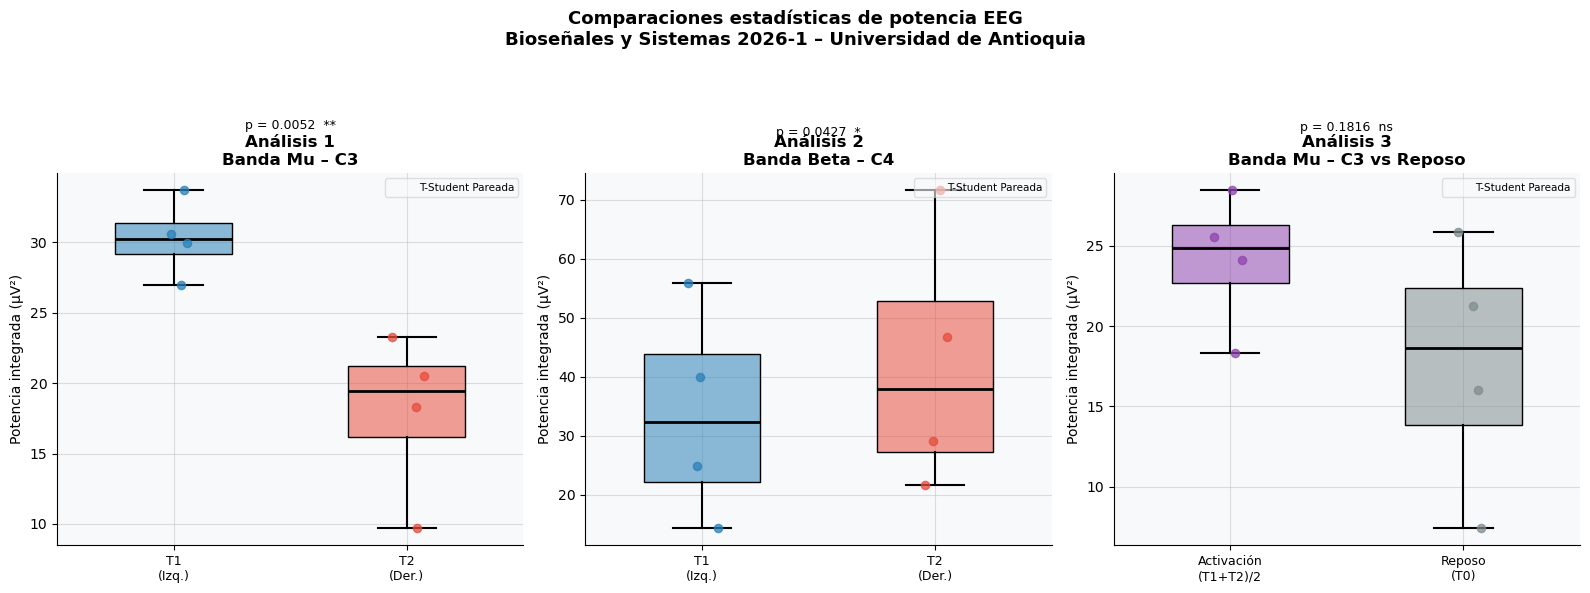

→ Figura guardada: figuras_BCI/analisis_estadistico_boxplot.png


In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle(
    "Comparaciones estadísticas de potencia EEG\n"
    "Bioseñales y Sistemas 2026-1 – Universidad de Antioquia",
    fontsize=13, fontweight='bold'
)

datos_plot = [
    (axes[0], df_analisis['Mu_C3_T1'].values,  df_analisis['Mu_C3_T2'].values,
     resultado_1, "T1\n(Izq.)", "T2\n(Der.)",  "Análisis 1\nBanda Mu – C3",   '#2980B9', '#E74C3C'),
    (axes[1], df_analisis['Beta_C4_T1'].values, df_analisis['Beta_C4_T2'].values,
     resultado_2, "T1\n(Izq.)", "T2\n(Der.)",  "Análisis 2\nBanda Beta – C4", '#2980B9', '#E74C3C'),
    (axes[2], mu_c3_activacion,                 df_analisis['Mu_C3_T0'].values,
     resultado_3, "Activación\n(T1+T2)/2", "Reposo\n(T0)",
     "Análisis 3\nBanda Mu – C3 vs Reposo",     '#8E44AD', '#7F8C8D'),
]

rng = np.random.default_rng(42)

for ax, dat_a, dat_b, res, etiq_a, etiq_b, titulo, col_a, col_b in datos_plot:
    bp = ax.boxplot(
        [dat_a, dat_b],
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markersize=4, alpha=0.5)
    )
    bp['boxes'][0].set_facecolor(col_a + '88')
    bp['boxes'][1].set_facecolor(col_b + '88')

    # Puntos individuales con jitter
    for i, (dat, col) in enumerate([(dat_a, col_a), (dat_b, col_b)], start=1):
        jitter = rng.uniform(-0.08, 0.08, size=len(dat))
        ax.scatter(np.full(len(dat), i) + jitter, dat,
                   color=col, alpha=0.75, s=35, zorder=3)

    # Anotación del p-valor
    y_max   = max(np.nanmax(dat_a), np.nanmax(dat_b))
    y_annot = y_max * 1.10
    p_v     = res['test_p']
    sig_str = ("***" if p_v < 0.001 else
               "**"  if p_v < 0.01  else
               "*"   if p_v < 0.05  else "ns")
    ax.annotate("", xy=(2, y_annot), xytext=(1, y_annot),
                arrowprops=dict(arrowstyle="-", color='black', lw=1.5))
    ax.text(1.5, y_annot * 1.02,
            f"p = {p_v:.4f}  {sig_str}",
            ha='center', va='bottom', fontsize=9)

    ax.set_xticks([1, 2])
    ax.set_xticklabels([etiq_a, etiq_b], fontsize=9)
    ax.set_ylabel("Potencia integrada (µV²)")
    ax.set_title(titulo, fontweight='bold')
    prueba_patch = mpatches.Patch(color='none', label=res['prueba'])
    ax.legend(handles=[prueba_patch], fontsize=7.5, loc='upper right', framealpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.93])
import os; os.makedirs('figuras_BCI', exist_ok=True)
plt.savefig('figuras_BCI/analisis_estadistico_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Figura guardada: figuras_BCI/analisis_estadistico_boxplot.png")

####  **Grafica 1**
El boxplot muestra una separación clara entre las dos condiciones. T1 presenta una distribución compacta y alta (mediana ≈ 30 µV², IQR estrecho), mientras que T2 tiene una distribución más dispersa y notablemente más baja (mediana ≈ 20 µV², con un valor atípico cercano a 10 µV²). Los cuatro puntos individuales son consistentes dentro de cada grupo, lo que refuerza la robustez visual de la diferencia.

#### **Grafica 2**
Los boxplots de T1 y T2 muestran una superposición considerable en sus rangos intercuartílicos, aunque las medianas difieren. T1 tiene una mediana ≈ 33 µV² con una distribución más concentrada en la parte baja, mientras que T2 presenta una mediana ≈ 40 µV² con mayor variabilidad (IQR amplio y un valor superior cercano a 70 µV²). La dispersión elevada en T2 explica por qué el p-valor (0.0427) queda cerca del límite de significancia.

#### **Grafica 3**
Los boxplots de ambas condiciones se superponen ampliamente. La condición de Activación (mediana ≈ 25 µV²) tiene un rango ligeramente más alto que Reposo (mediana ≈ 19 µV²), pero los IQR se traslapan casi completamente. Los puntos individuales muestran alta variabilidad en ambos grupos y no se observa una separación clara entre condiciones, lo cual es coherente con el resultado estadístico no significativo.

###  **b) Discusión**

#### **Análisis 1 – Banda Mu en C3: T1 (Izq.) vs T2 (Der.)**

C3 (hemisferio izquierdo) mostró significativamente mayor potencia Mu durante T1 que durante T2 (p = 0.0052). La caída de potencia observada en T2 es consistente con el fenómeno de Desincronización Relacionada con Eventos (ERD): durante la imaginación del movimiento de la mano derecha, el área sensoriomotora contralateral (hemisferio izquierdo, cubierta por C3) se activa y reduce su potencia en la banda Mu. Este patrón fue descrito sistemáticamente por Pfurtscheller y Lopes da Silva, quienes establecieron que la ERD en la banda Mu (8–13 Hz) sobre la corteza sensoriomotora contralateral es un marcador confiable tanto del movimiento real como del imaginado [20]. Adicionalmente, Neuper et al. demostraron que la imaginación motora activa representaciones corticales específicas que siguen el mismo patrón de lateralización que el movimiento ejecutado [21], lo que respalda que C3 discrimine eficazmente la lateralidad del movimiento imaginado como biomarcador para BCI.


#### **Análisis 2 – Banda Beta en C4: T1 (Izq.) vs T2 (Der.)**

 C4 (hemisferio derecho) mostró mayor potencia Beta durante T2, lo que implica mayor ERD en C4 durante T1 (imaginación izquierda), condición en la que C4 es el canal contralateral. Este resultado es coherente con la ERD en banda Beta (13–30 Hz) como segundo marcador clásico de activación sensoriomotora. Pfurtscheller et al. describieron que la ERD en Beta acompaña y sigue temporalmente a la ERD en Mu durante el movimiento e imaginación motora, especialmente en la fase de preparación y ejecución [22]. Por su parte, Kilavik et al. revisaron el rol de las oscilaciones Beta en el control motor, señalando que reflejan el estado de mantenimiento del sistema motor, de modo que su desincronización durante la imaginación motora indica la activación del plan motor contralateral [23]. La alta variabilidad observada en T2 es esperable dado que la magnitud de la ERD en Beta presenta diferencias interindividuales considerables, fenómeno documentado por Blankertz et al. en el contexto de BCI [24]. Junto con el resultado del Análisis 1, esto respalda el uso combinado de las bandas Mu y Beta en los electrodos C3–C4 como características para un clasificador BCI bilateral.

#### **Análisis 3 – Banda Mu en C3: Activación vs Reposo (T0)**
No se encontró evidencia estadística de que la imaginación motora produzca una ERD significativa respecto al reposo en C3 (p = 0.1816). Más aún, la media de activación (24.12 µV²) resultó numéricamente mayor que la del reposo (17.62 µV²), lo cual contradice la ERD esperada. Esto puede explicarse por tres razones. Primero, el poder estadístico con n = 4 es muy bajo: Cohen establece que para detectar efectos de tamaño mediano con α = 0.05 en pruebas pareadas se requieren al menos 26–34 sujetos, por lo que con 4 observaciones la probabilidad de cometer un error tipo II es alta [25]. Segundo, el promedio de T1 y T2 puede enmascarar patrones lateralizados opuestos, ya que la ERD es espacialmente específica y lateralizada, y promediar condiciones con activaciones en hemisferios opuestos puede producir cancelación parcial de la señal [20]. Tercero, la ERD en banda Mu durante imaginación motora presenta alta variabilidad interindividual, siendo más débil en sujetos con menor experiencia en tareas de neurofeedback o imaginería [26], lo que con muestras pequeñas genera distribuciones con solapamiento elevado. Este resultado no implica ausencia del fenómeno, sino insuficiencia de datos para detectarlo con la prueba aplicada.


###  **a) Conclusiones**

# Referencias

1. “EEG Motor Movement/Imagery Dataset - OpenNeuro,” Dec. 15, 2022. https://openneuro.org/datasets/ds004362/versions/1.0.0

2. J. R. Wolpaw, N. Birbaumer, D. J. McFarland, G. Pfurtscheller, and T. M. Vaughan, "Brain-computer interfaces for communication and control," Clinical Neurophysiology, vol. 113, no. 6, pp. 767-791, Jun. 2002.
3. H. Berger, "Über das Elektrenkephalogramm des Menschen," Archiv für Psychiatrie und Nervenkrankheiten, vol. 87, no. 1, pp. 527-570, Dec. 1929.
4.  J. J. Vidal, "Toward direct brain-computer communication," Annual Review of Biophysics and Bioengineering, vol. 2, no. 1, pp. 157-180, Jun. 1973.
5. L. A. Farwell and E. Donchin, "Talking off the top of your head: toward a mental prosthesis utilizing event-related brain potentials," Electroencephalography and Clinical Neurophysiology, vol. 70, no. 6, pp. 510-523, Dec. 1988.
6. NeuroSky and ZKTeco, "NeuroSky and ZKTeco announce joint venture to advance emotion-aware brain-computer interface technologies," Nov. 2025. [En línea]. Disponible en: https://neurosky.com [Accedido: 01-may-2026].
7. G. Pfurtscheller and C. Neuper, "Motor imagery and direct brain-computer communication," Proceedings of the IEEE, vol. 89, no. 7, pp. 1123-1134, Jul. 2001.
8. P. Lam, "BandRouteNet: An adaptive band routing neural network for EEG artifact removal," arXiv preprint arXiv:2604.24428v1, Abr. 2026.
9. ERC (European Research Council), "Enabling unobtrusive real-world monitoring of brain-networks with wearable neurotechnology and multimodal machine learning (INTEGRAL)," CORDIS, Ene. 2026. [En línea]. Disponible en: https://cordis.europa.eu [Accedido: 01-may-2026].
10. Stanford University, "New brain implants could restore motor, speech, visual functions," Stanford Medicine News, 2025. [En línea]. Disponible en: https://med.stanford.edu [Accedido: 01-may-2026].
11. ISR - University of Coimbra, "UpReGain: Gamified brain-machine interfaces for personalized upper-limb post-stroke rehabilitation," ISR - Institute of Systems and Robotics. [En línea]. Disponible en: https://www.isr.uc.pt [Accedido: 01-may-2026].
12. A. Paul, S. Pal, and M. Mitra, "A composite filter-based approach for artifact elimination and segmentation of EEG signal for application in brain-computer interface," Journal of Data Science and Intelligent Systems, vol. 4, no. 1, pp. 115-124, Ene. 2026.
13. G. Pfurtscheller and C. Neuper, “Motor imagery and direct brain-computer communication,” Proceedings of the IEEE, vol. 89, no. 7, pp. 1123–1134, 2001. https://doi.org/10.1109/5.939829 

14. J. R. Wolpaw, N. Birbaumer, D. J. McFarland, G. Pfurtscheller and T. M. Vaughan, “Brain–computer interfaces for communication and control,” Clinical Neurophysiology, vol. 113, no. 6, pp. 767–791, 2002. https://doi.org/10.1016/S1388-2457(02)00057-3 
15. E. Niedermeyer and F. L. da Silva, Electroencephalography: Basic Principles, Clinical Applications, and Related Fields, 5th ed. Philadelphia, PA, USA: Lippincott Williams & Wilkins, 2005. https://books.google.com/books?id=7bclAAAAMAAJ 
16. L. F. Nicolas-Alonso and J. Gomez-Gil, “Brain computer interfaces, a review,” Sensors, vol. 12, no. 2, pp. 1211–1279, 2012. https://doi.org/10.3390/s120201211 

17. Pfurtscheller, G., & Da Silva, F. L. (1999). Event-related EEG/MEG synchronization and desynchronization: basic principles. *Clinical neurophysiology*, 110(11), 1842-1857. *(Referencia principal para el análisis ERD/ERS y cálculo de potencia en tareas motoras).*
18. Widmann, A., Schröger, E., & Maess, B. (2015). Digital filter design for electrophysiological data–a practical approach. *Journal of neuroscience methods*, 250, 34-46. *(Estándar de oro que justifica el uso de filtros FIR y zero-phase en análisis offline).*
19. Bashashati, A., Fatourechi, M., Ward, R. K., & Birch, G. E. (2007). A survey of signal processing algorithms in brain–computer interfaces based on electrical brain signals. *Journal of Neural engineering*, 4(2), R32. *(Revisión masiva de los flujos de procesamiento, Welch y métodos estadísticos en BCI).*
20.R. B. Robinson, "The role of the $I_{f}$ current in cardiac rhythm," Ondina, vol. 42, no. 6, pp. 1157-1163, nov. 1999. Disponible en: https://pubmed.ncbi.nlm.nih.gov/10576479/
21.A. Bucchi, M. Baruscotti y D. DiFrancesco, "Current-dependent block of rabbit sino-atrial node $I_{f}$ channels by ivabradine," Pflugers Arch. - Eur. J. Physiol., vol. 453, no. 4, pp. 503-511, ene. 2007. Disponible en: https://pubmed.ncbi.nlm.nih.gov/17071233/
22.H. J. Duff, "Molecular and clinical biology of $I_{f}$: the pacemaker current," Can. J. Cardiol., vol. 27, no. 5, pp. 105-111, sep.-oct. 2011. Disponible en: https://pmc.ncbi.nlm.nih.gov/articles/PMC3198250/
23. B. E. Kilavik, M. Zaepffel, A. Brovelli, W. A. MacKay, and A. Riehle, "The ups and downs of beta oscillations in sensorimotor cortex," Experimental Neurology, vol. 245, pp. 15–26, 2013.
24. B. Blankertz, R. Tomioka, S. Lemm, M. Kawanabe, and K. R. Müller, "Optimizing spatial filters for robust EEG single-trial analysis," IEEE Signal Processing Magazine, vol. 25, no. 1, pp. 41–56, Jan. 2008.
25. J. Cohen, Statistical Power Analysis for the Behavioral Sciences, 2nd ed. Hillsdale, NJ, USA: Lawrence Erlbaum Associates, 1988.
26.S. G. Priori et al., "HCN4 mutations in patients with sinoatrial node dysfunction," J. Am. Coll. Cardiol., vol. 72, no. 7, pp. 758-769, ago. 2018. Disponible en: https://pmc.ncbi.nlm.nih.gov/articles/PMC6089230/

